# OceanWatch Analytics — Entrega 1
## El lakehouse del tráfico marítimo (AIS · NOAA)

**Curso:** MINE 4213 · Soluciones Intensivas en Datos · 2026-20
**Entrega 1 · Databricks Free Edition (Serverless)**

Este notebook cubre la parte de **ingesta documentada** (Req. 1) y **exploración y
perfilamiento** (Req. 2) del proyecto, más una batería amplia de visualizaciones.
Las **preguntas de negocio** (Req. 3) y el resto (almacenamiento óptimo, gobernanza)
se desarrollan en secciones posteriores / notebooks aparte.

### Alcance de este notebook
1. **Ingesta documentada** — descarga de los 7 días (1–7 jun 2023) desde la fuente oficial
   NOAA, con reintentos y verificación de integridad; descompresión en un Volume de Unity
   Catalog; lectura de los CSV con **esquema explícito**.
2. **Exploración y perfilamiento** — posiciones por día, buques únicos, distribución por
   tipo de buque y tamaño; detección y cuantificación de problemas de calidad de datos.
3. **Visualizaciones** — la mayor cantidad posible de gráficas, cuidadas y legibles.

> **Nota metodológica.** Con ~150M de filas no se puede traer el dataset completo al driver.
> El patrón que seguimos es: **agregar con Spark** (resultado pequeño) → 'toPandas()' →
> graficar; y para distribuciones finas usamos **muestreo** ('sample'). Así las gráficas son
> reproducibles y defendibles con el criterio de *Spark eficiente*.

## 0. Configuración e imports

Todos los parámetros de nombres (catálogo, esquema, volume) están centralizados aquí para
poder cambiarlos en un solo lugar. Ajusta estos valores si tu workspace usa otros nombres.

In [0]:
# Parámetros del proyecto
CATALOG = "oceanwatch"      # catálogo de Unity Catalog
SCHEMA = "entrega1"         # esquema/base de datos del proyecto
VOLUME = "landing"          # volume donde aterrizan zips y CSV

# Rutas derivadas dentro del Volume (aterrizaje de datos crudos)
VOLUME_ROOT = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"
ZIP_DIR = f"{VOLUME_ROOT}/zips"      # archivos .zip descargados
CSV_DIR = f"{VOLUME_ROOT}/csv"       # CSV descomprimidos
CKPT_DIR = f"{VOLUME_ROOT}/_meta"    # metadatos de ingesta (integridad, logs)

# Días del corpus de la Entrega 1: 1 al 7 de junio de 2023
DAYS = [f"2023_06_{d:02d}" for d in range(1, 8)]
BASE_URL = "https://coast.noaa.gov/htdata/CMSP/AISDataHandler/2023"

# Semilla y tamaños de muestreo para gráficas (reproducibilidad)
SEED = 42
SAMPLE_FRACTION = 0.01 

print("Catálogo :", CATALOG)
print("Esquema  :", SCHEMA)
print("Volume   :", VOLUME_ROOT)
print("Días     :", DAYS)

Catálogo : oceanwatch
Esquema  : entrega1
Volume   : /Volumes/oceanwatch/entrega1/landing
Días     : ['2023_06_01', '2023_06_02', '2023_06_03', '2023_06_04', '2023_06_05', '2023_06_06', '2023_06_07']


In [0]:
import os
import time
import hashlib
import urllib.request
import urllib.error
import zipfile
import json

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

# Estilo visual unificado para todas las gráficas
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.autolayout"] = True
plt.rcParams["savefig.bbox"] = "tight"

# Paleta consistente del proyecto (tonos "oceánicos")
OCEAN_PALETTE = sns.color_palette("crest", as_cmap=False, n_colors=10)
OCEAN_SEQ = "crest"       # colormap secuencial (mapas de calor, densidades)
ACCENT = "#0b6e99"        # azul de acento para series simples
sns.set_palette("crest")


def format_millions(x, pos):
    """Formatea el eje en millones (M) o miles (K) para legibilidad."""
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"


MILLIONS_FMT = mticker.FuncFormatter(format_millions)


def annotate_bars(ax, orient="v", fmt="{:,.0f}", fontsize=10, padding=3):
    """Anota barras con su valor. orient='v' (vertical) u 'h' (horizontal)."""
    for container in ax.containers:
        labels = [fmt.format(v) for v in (container.datavalues if hasattr(container, "datavalues") else [])]
        ax.bar_label(container, labels=labels or None, fontsize=fontsize, padding=padding)


print("Imports y estilo visual listos.")

Imports y estilo visual listos.


## 1. Ingesta documentada (Req. 1)

Objetivo del requisito: descargar los 7 días desde la fuente oficial dentro del notebook.
(con reintentos y verificación de integridad), descomprimir en el Volume y leer los CSV
con esquema explícito**.

Estructura de la ingesta:
1. Crear catálogo, esquema y volume en Unity Catalog.
2. Descargar cada zip con reintentos exponenciales y verificación (tamaño + hash + zip válido).
3. Descomprimir los CSV en el Volume.
4. Leer con esquema explícito (nada de 'inferSchema', que es caro y frágil sobre datos crudos).

### 1.1 Unity Catalog: catálogo, esquema y volume

Creamos el contenedor lógico del proyecto. El **Volume** es el almacenamiento gobernado donde
aterrizan los archivos crudos (los zip no se leen directo con Spark: primero se descomprimen).

In [0]:
spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")
spark.sql(f"CREATE VOLUME IF NOT EXISTS {CATALOG}.{SCHEMA}.{VOLUME}")

# Comentario/metadato del esquema (aporta a la parte de gobernanza)
spark.sql(f"""
    COMMENT ON SCHEMA {CATALOG}.{SCHEMA} IS
    'OceanWatch Analytics — Entrega 1. Datos AIS (NOAA) 1-7 jun 2023: ingesta, perfilamiento y calidad.'
""")

# Subdirectorios dentro del Volume
for d in (ZIP_DIR, CSV_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

spark.sql(f"USE CATALOG {CATALOG}")
spark.sql(f"USE SCHEMA {SCHEMA}")

print("Unity Catalog listo.")
print("  Zips :", ZIP_DIR)
print("  CSV  :", CSV_DIR)
print("  Meta :", CKPT_DIR)

Unity Catalog listo.
  Zips : /Volumes/oceanwatch/entrega1/landing/zips
  CSV  : /Volumes/oceanwatch/entrega1/landing/csv
  Meta : /Volumes/oceanwatch/entrega1/landing/_meta


### 1.2 Descarga con reintentos y verificación de integridad

La descarga es idempotente: si el zip ya existe y es válido, no se vuelve a bajar. Para cada
archivo verificamos:
- **Descarga completa**: el tamaño en disco coincide con 'Content-Length' del servidor.
- **Integridad del zip**: 'zipfile.testzip()' no reporta miembros corruptos.
- **Hash SHA-256**: se calcula y se guarda como huella reproducible del archivo.

Los reintentos usan "backoff exponencial". Todo el resultado se registra en un manifiesto JSON
dentro del Volume, que sirve como evidencia de la ingesta.

In [0]:
def _sha256(path, chunk=1 << 20):
    """SHA-256 de un archivo, leyendo en bloques para no cargarlo en memoria."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def _is_valid_zip(path):
    """True si el archivo existe y es un zip íntegro (ningún miembro corrupto)."""
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path) as zf:
            return zf.testzip() is None
    except zipfile.BadZipFile:
        return False


def download_with_retries(url, dest, max_retries=4, timeout=120):
    """
    Descarga 'url' a 'dest' con reintentos y backoff exponencial.
    Verifica el tamaño contra Content-Length y devuelve un dict con evidencia.
    Idempotente: si 'dest' ya es un zip válido, no re-descarga.
    """
    if _is_valid_zip(dest):
        size = os.path.getsize(dest)
        return {"url": url, "dest": dest, "status": "cached", "bytes": size,
                "sha256": _sha256(dest), "attempts": 0}

    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            t0 = time.time()
            req = urllib.request.Request(url, headers={"User-Agent": "OceanWatch/1.0"})
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                expected = resp.headers.get("Content-Length")
                expected = int(expected) if expected is not None else None
                with open(dest, "wb") as out:
                    while True:
                        buf = resp.read(1 << 20)  # 1 MB
                        if not buf:
                            break
                        out.write(buf)
            dt = time.time() - t0
            got = os.path.getsize(dest)

            # Verificación de integridad: tamaño esperado + zip válido
            if expected is not None and got != expected:
                raise IOError(f"tamaño incompleto: {got} != Content-Length {expected}")
            if not _is_valid_zip(dest):
                raise zipfile.BadZipFile("zip corrupto tras la descarga")

            return {"url": url, "dest": dest, "status": "downloaded", "bytes": got,
                    "content_length": expected, "sha256": _sha256(dest),
                    "seconds": round(dt, 1), "attempts": attempt}
        except (urllib.error.URLError, IOError, zipfile.BadZipFile) as e:
            last_err = str(e)
            if os.path.exists(dest):
                os.remove(dest)  # limpiar archivo parcial antes de reintentar
            if attempt < max_retries:
                backoff = 2 ** attempt
                print(f"  intento {attempt} falló ({last_err}); reintento en {backoff}s")
                time.sleep(backoff)

    return {"url": url, "dest": dest, "status": "failed", "error": last_err,
            "attempts": max_retries}


# Descargar los 7 días
ingest_manifest = []
for day in DAYS:
    fname = f"AIS_{day}.zip"
    url = f"{BASE_URL}/{fname}"
    dest = f"{ZIP_DIR}/{fname}"
    print(f"→ {fname}")
    result = download_with_retries(url, dest)
    result["day"] = day
    ingest_manifest.append(result)
    print(f"  {result['status']} · {result.get('bytes', 0)/1e6:.1f} MB · "
          f"intentos={result.get('attempts')}")

# Persistir manifiesto de ingesta como evidencia
manifest_path = f"{CKPT_DIR}/ingest_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(ingest_manifest, f, indent=2)
print("\nManifiesto de ingesta guardado en:", manifest_path)

→ AIS_2023_06_01.zip
  downloaded · 343.9 MB · intentos=1
→ AIS_2023_06_02.zip
  downloaded · 354.1 MB · intentos=1
→ AIS_2023_06_03.zip
  downloaded · 312.2 MB · intentos=1
→ AIS_2023_06_04.zip
  downloaded · 332.5 MB · intentos=1
→ AIS_2023_06_05.zip
  intento 1 falló (tamaño incompleto: 139509403 != Content-Length 335658758); reintento en 2s
  downloaded · 335.7 MB · intentos=2
→ AIS_2023_06_06.zip
  downloaded · 335.3 MB · intentos=1
→ AIS_2023_06_07.zip
  downloaded · 347.9 MB · intentos=1

Manifiesto de ingesta guardado en: /Volumes/oceanwatch/entrega1/landing/_meta/ingest_manifest.json


#### Resumen de la descarga (evidencia de integridad)

Tabla con estado, tamaño, número de intentos y hash SHA-256 de cada archivo. Si algún archivo
quedó en estado 'failed', hay que volver a ejecutar la celda de descarga antes de continuar.

In [0]:
manifest_df = pd.DataFrame(ingest_manifest)
cols = [c for c in ["day", "status", "bytes", "content_length", "attempts", "seconds", "sha256"]
        if c in manifest_df.columns]
manifest_df = manifest_df[cols]
if "bytes" in manifest_df:
    manifest_df["MB"] = (manifest_df["bytes"] / 1e6).round(1)
display(manifest_df)

n_failed = sum(1 for r in ingest_manifest if r["status"] == "failed")
assert n_failed == 0, f"{n_failed} descargas fallaron; re-ejecuta la celda de descarga."
print("Todas las descargas verificadas correctamente.")

day,status,bytes,content_length,attempts,seconds,sha256,MB
2023_06_01,downloaded,343949892,343949892,1,52.5,e6287c47f9659fd3bc6c0456579e93f07e3ec099c347514757a86413d0c99d6a,343.9
2023_06_02,downloaded,354145683,354145683,1,16.5,9f01ff4c3a21240c41ed0ca64a945be7fb8bee0f5bff049dc5c3e727aa02b8ac,354.1
2023_06_03,downloaded,312248025,312248025,1,22.8,070ccec839de290cba810308753b56d2bac6839a9fd076df6ab089b525e046c8,312.2
2023_06_04,downloaded,332457486,332457486,1,10.7,396efd491ea992aded336ba85bfed1cd8079baf294fb1fadf215e69d40ed42a0,332.5
2023_06_05,downloaded,335658758,335658758,2,17.1,00899e6450a4cc3170059ed990c94e060257e86f22edd5c6683f282e5ce7f4c8,335.7
2023_06_06,downloaded,335300028,335300028,1,17.0,c8b4acd430a675fbffe3665d9ed9843ce0696c947e4d35411a504ad2ffc595f4,335.3
2023_06_07,downloaded,347918296,347918296,1,35.4,03b9b5ddb1247f08a4c3bab738c7b6c569c93094f82e8830cfea4853f9a5bed7,347.9


Todas las descargas verificadas correctamente.


### 1.3 Descompresión en el Volume

Los zip no se leen directamente con Spark. Extraemos cada CSV al directorio 'csv/' del Volume.
La operación también es idempotente: si el CSV ya existe con tamaño > 0, no se re-extrae.

In [0]:
extract_log = []
for day in DAYS:
    zip_path = f"{ZIP_DIR}/AIS_{day}.zip"
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.namelist():
            if not member.lower().endswith(".csv"):
                continue
            out_name = os.path.basename(member)
            out_path = f"{CSV_DIR}/{out_name}"
            if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
                extract_log.append({"day": day, "csv": out_name,
                                    "status": "cached",
                                    "bytes": os.path.getsize(out_path)})
                continue
            # Extraer de forma segura al directorio de CSV
            with zf.open(member) as src, open(out_path, "wb") as dst:
                while True:
                    buf = src.read(1 << 20)
                    if not buf:
                        break
                    dst.write(buf)
            extract_log.append({"day": day, "csv": out_name,
                                "status": "extracted",
                                "bytes": os.path.getsize(out_path)})
            print(f"  extraído {out_name} ({os.path.getsize(out_path)/1e6:.1f} MB)")

extract_df = pd.DataFrame(extract_log)
extract_df["MB"] = (extract_df["bytes"] / 1e6).round(1)
display(extract_df)
print("CSV disponibles en:", CSV_DIR)

  extraído AIS_2023_06_01.csv (943.4 MB)
  extraído AIS_2023_06_02.csv (969.4 MB)
  extraído AIS_2023_06_03.csv (860.5 MB)
  extraído AIS_2023_06_04.csv (913.3 MB)
  extraído AIS_2023_06_05.csv (922.8 MB)
  extraído AIS_2023_06_06.csv (918.8 MB)
  extraído AIS_2023_06_07.csv (953.6 MB)


day,csv,status,bytes,MB
2023_06_01,AIS_2023_06_01.csv,extracted,943431681,943.4
2023_06_02,AIS_2023_06_02.csv,extracted,969444078,969.4
2023_06_03,AIS_2023_06_03.csv,extracted,860511883,860.5
2023_06_04,AIS_2023_06_04.csv,extracted,913283650,913.3
2023_06_05,AIS_2023_06_05.csv,extracted,922808494,922.8
2023_06_06,AIS_2023_06_06.csv,extracted,918827336,918.8
2023_06_07,AIS_2023_06_07.csv,extracted,953614322,953.6


CSV disponibles en: /Volumes/oceanwatch/entrega1/landing/csv


### 1.4 Esquema explícito y lectura de los CSV

Definimos el esquema explícitamente (no usamos 'inferSchema'): sobre 150M de filas, inferir
implica una pasada extra de lectura y expone a errores de tipado ante datos sucios. Declararlo
nos da control y rendimiento.

Las columnas siguen la referencia del estándar AIS de Marine Cadastre. Añadimos:
- 'source_file' con 'INPUT_FILE_NAME()' (trazabilidad, es útil para el Req. 4).
- 'date' derivada de 'BaseDateTime' (para agregados diarios).

In [0]:
ais_schema = T.StructType([
    T.StructField("MMSI", T.LongType(), True),
    T.StructField("BaseDateTime", T.TimestampType(), True),
    T.StructField("LAT", T.DoubleType(), True),
    T.StructField("LON", T.DoubleType(), True),
    T.StructField("SOG", T.DoubleType(), True),   # Speed Over Ground (nudos)
    T.StructField("COG", T.DoubleType(), True),   # Course Over Ground (grados)
    T.StructField("Heading", T.DoubleType(), True),
    T.StructField("VesselName", T.StringType(), True),
    T.StructField("IMO", T.StringType(), True),
    T.StructField("CallSign", T.StringType(), True),
    T.StructField("VesselType", T.IntegerType(), True),
    T.StructField("Status", T.StringType(), True),
    T.StructField("Length", T.DoubleType(), True),
    T.StructField("Width", T.DoubleType(), True),
    T.StructField("Draft", T.DoubleType(), True),
    T.StructField("Cargo", T.IntegerType(), True),
    T.StructField("TransceiverClass", T.StringType(), True),
])

raw = (
    spark.read
    .option("header", True)
    .option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ss")
    .schema(ais_schema)
    .csv(f"{CSV_DIR}/*.csv")
    .withColumn("source_file", F.col("_metadata.file_path"))
    .withColumn("date", F.to_date("BaseDateTime"))
)

# Vista temporal para consultas SQL exploratorias
raw.createOrReplaceTempView("ais_raw")
print("Esquema de lectura:")
raw.printSchema()

Esquema de lectura:
root
 |-- MMSI: long (nullable = true)
 |-- BaseDateTime: timestamp (nullable = true)
 |-- LAT: double (nullable = true)
 |-- LON: double (nullable = true)
 |-- SOG: double (nullable = true)
 |-- COG: double (nullable = true)
 |-- Heading: double (nullable = true)
 |-- VesselName: string (nullable = true)
 |-- IMO: string (nullable = true)
 |-- CallSign: string (nullable = true)
 |-- VesselType: integer (nullable = true)
 |-- Status: string (nullable = true)
 |-- Length: double (nullable = true)
 |-- Width: double (nullable = true)
 |-- Draft: double (nullable = true)
 |-- Cargo: integer (nullable = true)
 |-- TransceiverClass: string (nullable = true)
 |-- source_file: string (nullable = false)
 |-- date: date (nullable = true)



#### Confirmación de columnas reales vs. referencia

El enunciado pide *verificar las columnas exactas de sus archivos*. Comparamos el encabezado
real del CSV contra el esquema declarado para dejar constancia de cualquier diferencia.

In [0]:
# Encabezado real del primer CSV (una sola fila leída como texto)
sample_csv = sorted([f for f in os.listdir(CSV_DIR) if f.lower().endswith(".csv")])[0]
with open(f"{CSV_DIR}/{sample_csv}") as f:
    header_real = f.readline().strip().split(",")

schema_cols = [fld.name for fld in ais_schema.fields]
solo_en_archivo = [c for c in header_real if c not in schema_cols]
solo_en_esquema = [c for c in schema_cols if c not in header_real]

print("Archivo de referencia :", sample_csv)
print("Columnas en el archivo :", header_real)
print("Solo en el archivo (no declaradas):", solo_en_archivo or "ninguna")
print("Solo en el esquema (no presentes):", solo_en_esquema or "ninguna")

Archivo de referencia : AIS_2023_06_01.csv
Columnas en el archivo : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass']
Solo en el archivo (no declaradas): ninguna
Solo en el esquema (no presentes): ninguna


## 2. Exploración y perfilamiento (Req. 2)

Buscamos obtener información sobre posiciones por día, buques únicos, distribución por tipo de buque y
tamaño; e identificar y cuantificar los problemas de calidad (posiciones fuera de rango,
velocidades imposibles, identificadores anómalos, duplicados, etc.). Ese diagnóstico es la
materia prima de la Entrega 2.

Todo se agrega con Spark; solo los resultados (pequeños) bajan al driver para graficar.

### 2.1 Panorama general del corpus

Conteos globales: total de filas, buques únicos, rango temporal y número de días/archivos.

In [0]:
overview = raw.agg(
    F.count("*").alias("total_posiciones"),
    F.countDistinct("MMSI").alias("buques_unicos"),
    F.min("BaseDateTime").alias("min_fecha"),
    F.max("BaseDateTime").alias("max_fecha"),
    F.countDistinct("date").alias("dias_distintos"),
    F.countDistinct("source_file").alias("archivos"),
).collect()[0]

print(" PANORAMA GENERAL")
print(f"Total de posiciones : {overview['total_posiciones']:,}")
print(f"Buques únicos (MMSI): {overview['buques_unicos']:,}")
print(f"Rango temporal      : {overview['min_fecha']}  →  {overview['max_fecha']}")
print(f"Días distintos      : {overview['dias_distintos']}")
print(f"Archivos fuente     : {overview['archivos']}")

──────────── PANORAMA GENERAL ────────────
Total de posiciones : 60,533,559
Buques únicos (MMSI): 31,871
Rango temporal      : 2023-06-01 00:00:00  →  2023-06-07 23:59:59
Días distintos      : 7
Archivos fuente     : 7


### 2.2 Posiciones por día

In [0]:
pos_por_dia = (
    raw.groupBy("date")
    .agg(F.count("*").alias("posiciones"),
         F.countDistinct("MMSI").alias("buques_unicos"))
    .orderBy("date")
    .toPandas()
)
pos_por_dia["date"] = pd.to_datetime(pos_por_dia["date"])
display(pos_por_dia)

date,posiciones,buques_unicos
2023-06-01T00:00:00.000Z,8808904,20448
2023-06-02T00:00:00.000Z,9052241,21153
2023-06-03T00:00:00.000Z,8036348,20505
2023-06-04T00:00:00.000Z,8522645,19720
2023-06-05T00:00:00.000Z,8613757,19615
2023-06-06T00:00:00.000Z,8587938,19717
2023-06-07T00:00:00.000Z,8911726,20086


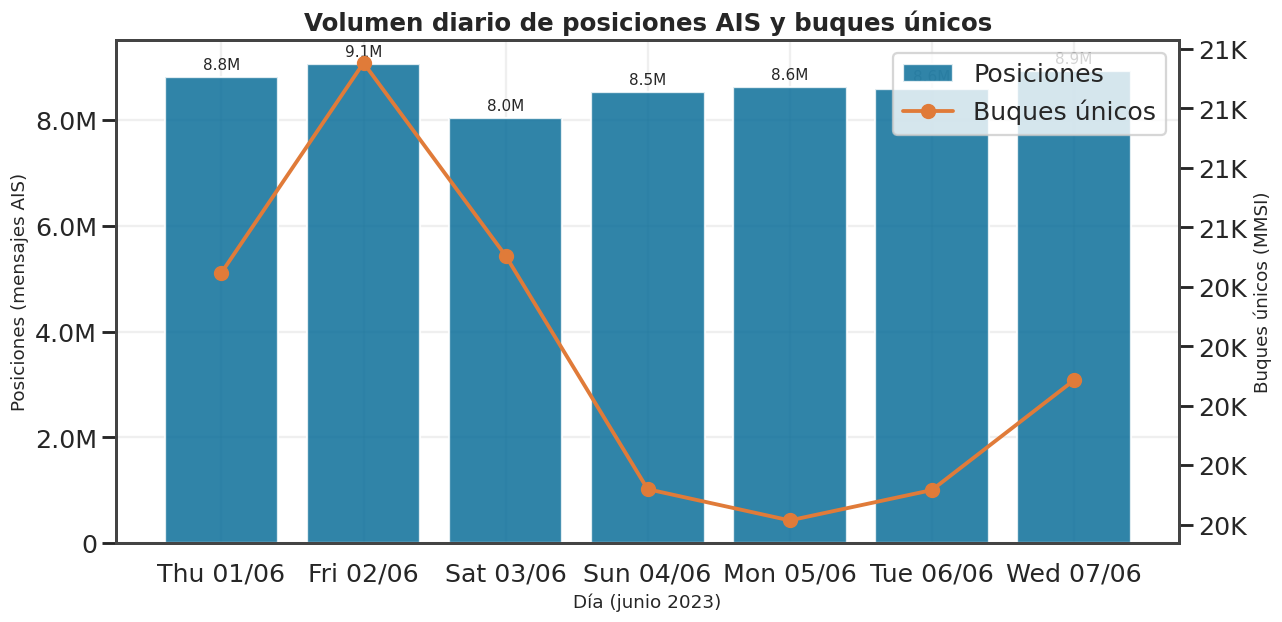

In [0]:
# Gráfica: posiciones por día (barras) con buques únicos superpuestos (línea, eje secundario)
fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(pos_por_dia["date"].dt.strftime("%a %d/%m"), pos_por_dia["posiciones"],
               color=ACCENT, alpha=0.85, label="Posiciones")
ax1.set_ylabel("Posiciones (mensajes AIS)")
ax1.set_xlabel("Día (junio 2023)")
ax1.set_title("Volumen diario de posiciones AIS y buques únicos")
ax1.yaxis.set_major_formatter(MILLIONS_FMT)
ax1.bar_label(bars, labels=[format_millions(v, None) for v in pos_por_dia["posiciones"]],
              padding=3, fontsize=10)

ax2 = ax1.twinx()
ax2.plot(pos_por_dia["date"].dt.strftime("%a %d/%m"), pos_por_dia["buques_unicos"],
         color="#e07b39", marker="o", linewidth=2.5, label="Buques únicos")
ax2.set_ylabel("Buques únicos (MMSI)")
ax2.yaxis.set_major_formatter(MILLIONS_FMT)
ax2.grid(False)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)
plt.show()

**Análisis.** El corpus tiene **60.5M de posiciones** de **31,871 buques** en la semana. El
volumen diario es muy estable (~8–9M de posiciones/día) y los buques únicos por día se mantienen en la
franja **19,600–21,100**, sin caída marcada en fin de semana: el tráfico monitoreado por AIS es una
operación continua, no sujeta a jornada laboral. La línea de buques únicos acompaña al volumen sin
proporcionalidad estricta, lo que anticipa que **unos pocos buques emiten muchísimos mensajes**.

### 2.3 Buques únicos por día y tasa de transmisión

Además del conteo, miramos la **intensidad de transmisión**: posiciones promedio por buque y
por día (mensajes que emite un buque típico en un día).

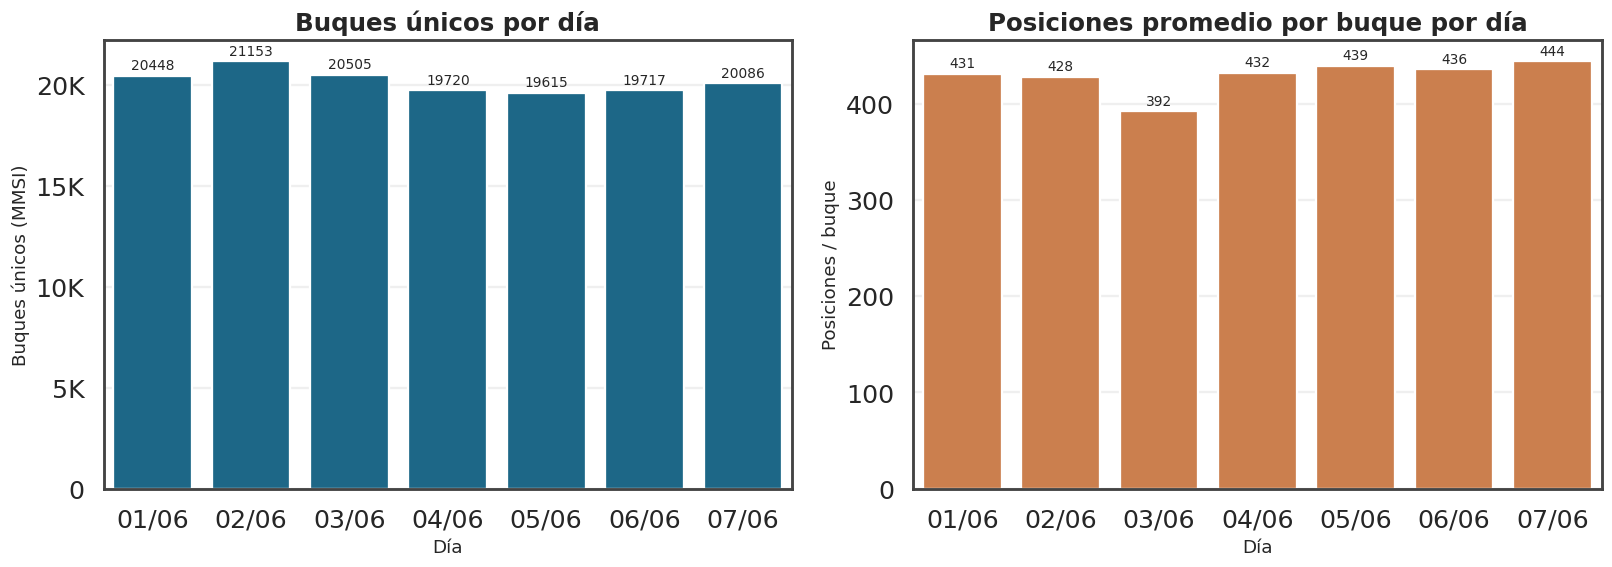

In [0]:
pos_por_dia["pos_por_buque"] = pos_por_dia["posiciones"] / pos_por_dia["buques_unicos"]

fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(data=pos_por_dia, x=pos_por_dia["date"].dt.strftime("%d/%m"),
            y="buques_unicos", ax=axa, color=ACCENT)
axa.set_title("Buques únicos por día")
axa.set_xlabel("Día")
axa.set_ylabel("Buques únicos (MMSI)")
axa.yaxis.set_major_formatter(MILLIONS_FMT)
for c in axa.containers:
    axa.bar_label(c, fmt="%.0f", fontsize=9, padding=2)

sns.barplot(data=pos_por_dia, x=pos_por_dia["date"].dt.strftime("%d/%m"),
            y="pos_por_buque", ax=axb, color="#e07b39")
axb.set_title("Posiciones promedio por buque por día")
axb.set_xlabel("Día")
axb.set_ylabel("Posiciones / buque")
for c in axb.containers:
    axb.bar_label(c, fmt="%.0f", fontsize=9, padding=2)

plt.show()

**Análisis.** El número de buques activos es notablemente estable día a día (variación < 8%
entre el mínimo y el máximo), lo que confirma una población de buques persistente en las aguas
monitoreadas. La tasa de **posiciones por buque por día** (del orden de varios centenares) es coherente
con la frecuencia de emisión del AIS (un mensaje cada pocos segundos cuando el buque navega, menos
cuando está fondeado), y explica por qué el volumen total escala con la actividad, no solo con el
número de buques.

### 2.4 Catálogo de tipos de buque (VesselType AIS)

'VesselType' es un código numérico del estándar AIS. Construimos un catálogo que mapea el código
a una **categoría legible** por rangos (Wing-in-ground, Fishing, Tug/Towing, Passenger, Cargo,
Tanker, etc.), para poder etiquetar las gráficas por categoría.

In [0]:
def vessel_category(code):
    """Mapea el código VesselType AIS a una categoría legible (según rangos del estándar)."""
    if code is None or pd.isna(code):
        return "Desconocido"
    c = int(code)
    if c == 0:
        return "No disponible / default"
    if 1 <= c <= 19:
        return "Reservado"
    if 20 <= c <= 29:
        return "Wing in ground (WIG)"
    if c == 30:
        return "Fishing"
    if c in (31, 32):
        return "Towing"
    if c == 33:
        return "Dredging / underwater ops"
    if c == 34:
        return "Diving ops"
    if c == 35:
        return "Military ops"
    if c == 36:
        return "Sailing"
    if c == 37:
        return "Pleasure craft"
    if 40 <= c <= 49:
        return "High speed craft (HSC)"
    if c == 50:
        return "Pilot vessel"
    if c == 51:
        return "Search and rescue"
    if c == 52:
        return "Tug"
    if c == 53:
        return "Port tender"
    if c == 55:
        return "Law enforcement"
    if c in (58,):
        return "Medical transport"
    if 60 <= c <= 69:
        return "Passenger"
    if 70 <= c <= 79:
        return "Cargo"
    if 80 <= c <= 89:
        return "Tanker"
    if 90 <= c <= 99:
        return "Other"
    return "Otro / no mapeado"


vessel_category_udf = F.udf(vessel_category, T.StringType())

# Tabla catálogo persistida (aporta a gobernanza: metadatos legibles de los códigos)
codes = raw.select("VesselType").distinct().toPandas()
codes["categoria"] = codes["VesselType"].apply(vessel_category)
vessel_catalog_sdf = spark.createDataFrame(codes.rename(columns={"VesselType": "vessel_type"}))
(vessel_catalog_sdf.write.mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(f"{CATALOG}.{SCHEMA}.vessel_type_catalog"))
spark.sql(f"""COMMENT ON TABLE {CATALOG}.{SCHEMA}.vessel_type_catalog IS
    'Catálogo de códigos VesselType (AIS) a categoría legible.'""")
display(codes.sort_values("VesselType"))

### 2.5 Distribución por tipo de buque

Dos miradas: por **número de posiciones** (volumen de tráfico que genera cada categoría) y por
**número de buques únicos** (cuántos barcos distintos hay de cada categoría). No son lo mismo:
una categoría puede tener pocos buques que transmiten muchísimo.

In [0]:
tipo_pos = (
    raw.withColumn("categoria", vessel_category_udf("VesselType"))
    .groupBy("categoria")
    .agg(F.count("*").alias("posiciones"),
         F.countDistinct("MMSI").alias("buques"))
    .orderBy(F.desc("posiciones"))
    .toPandas()
)
display(tipo_pos)

categoria,posiciones,buques
Towing,16657406,3476
Pleasure craft,14476696,12934
Passenger,5008900,1774
Cargo,4368575,1800
Other,4275801,1678
Fishing,4010188,2192
Sailing,3876264,4243
Tanker,2074793,954
Tug,1921565,482
Otro / no mapeado,1472081,324


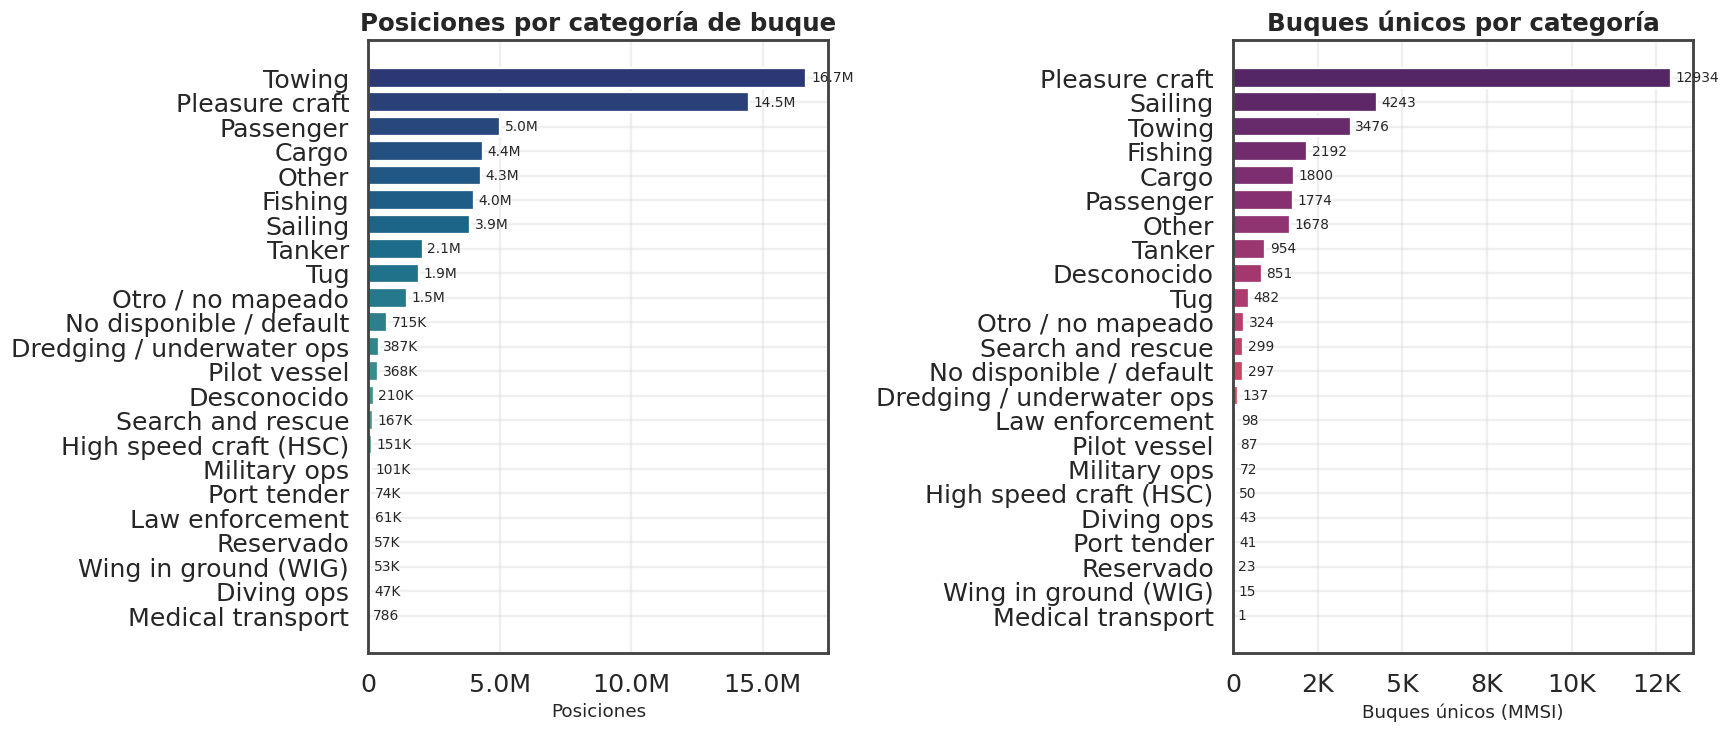

In [0]:
fig, (axp, axb) = plt.subplots(1, 2, figsize=(16, 7))

top_pos = tipo_pos.sort_values("posiciones", ascending=True)
axp.barh(top_pos["categoria"], top_pos["posiciones"], color=sns.color_palette(OCEAN_SEQ, len(top_pos)))
axp.set_title("Posiciones por categoría de buque")
axp.set_xlabel("Posiciones")
axp.xaxis.set_major_formatter(MILLIONS_FMT)
for c in axp.containers:
    axp.bar_label(c, labels=[format_millions(v, None) for v in top_pos["posiciones"]],
                  padding=3, fontsize=9)

top_b = tipo_pos.sort_values("buques", ascending=True)
axb.barh(top_b["categoria"], top_b["buques"], color=sns.color_palette("flare", len(top_b)))
axb.set_title("Buques únicos por categoría")
axb.set_xlabel("Buques únicos (MMSI)")
axb.xaxis.set_major_formatter(MILLIONS_FMT)
for c in axb.containers:
    axb.bar_label(c, fmt="%.0f", padding=3, fontsize=9)

plt.show()

**Análisis.** Hay una disociación clara entre **volumen de tráfico** y **número de buques**.
*Towing* (remolcadores/empujadores) genera el mayor tráfico (**16.7M posiciones**) con solo **3,476
buques**: pocos buques que transmiten sin parar. En contraste, *Pleasure craft* tiene casi la misma
cantidad de posiciones (**14.5M**) pero repartidas entre **12,934 buques**, la flota más numerosa.
Categorías como *Cargo* o *Tanker* aportan tráfico relevante con flotas medianas. Aparecen códigos
"No disponible/default" y "Desconocido", que se retoman en calidad.

#### Participación relativa (treemap textual / top categorías)

/home/spark-a9dd7b4e-8de5-46e1-8cbf-08/.ipykernel/71/command-4598901876618815-3169783122:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="categoria", x="pct", ax=ax,


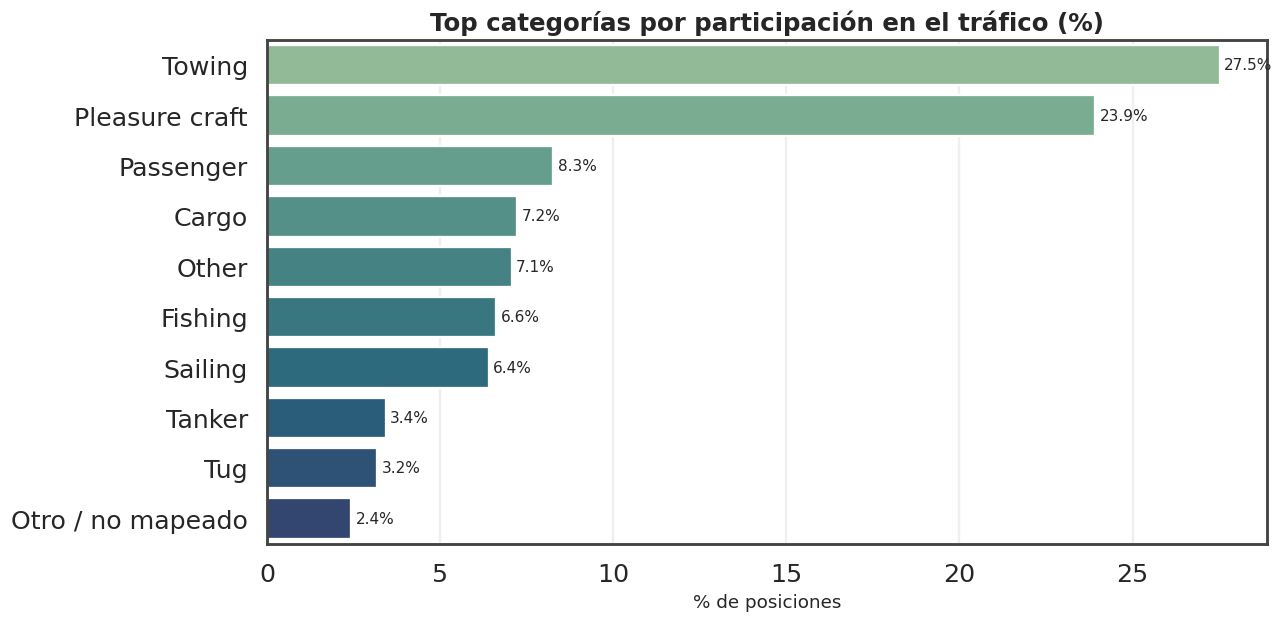

In [0]:
fig, ax = plt.subplots(figsize=(12, 6))
total = tipo_pos["posiciones"].sum()
top10 = tipo_pos.nlargest(10, "posiciones").copy()
top10["pct"] = 100 * top10["posiciones"] / total
sns.barplot(data=top10, y="categoria", x="pct", ax=ax,
            palette=sns.color_palette(OCEAN_SEQ, len(top10)))
ax.set_title("Top categorías por participación en el tráfico (%)")
ax.set_xlabel("% de posiciones")
ax.set_ylabel("")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3, fontsize=10)
plt.show()

**Análisis.** El tráfico está muy concentrado por tipo: **Towing + Pleasure craft** suman
por sí solas más de la mitad de todas las posiciones de la semana. Esta concentración es relevante para
la Entrega 2, porque las reglas de calidad y las optimizaciones tendrán el mayor impacto sobre estas
dos categorías dominantes.

### 2.6 Distribución por tamaño de buque (Length, Width, Draft)

El tamaño es un atributo por buque, no por mensaje. Para no sesgar por los buques que más
transmiten, tomamos **un valor por MMSI** (la mediana de cada dimensión por buque) y luego
describimos la población de buques.

In [0]:
# Se hace un registro por buque: mediana de Length/Width/Draft (percentil 50 aprox.)
dims_por_buque = (
    raw.groupBy("MMSI")
    .agg(F.expr("percentile_approx(Length, 0.5)").alias("Length"),
         F.expr("percentile_approx(Width, 0.5)").alias("Width"),
         F.expr("percentile_approx(Draft, 0.5)").alias("Draft"),
         F.first("VesselType", ignorenulls=True).alias("VesselType"))
)
dims_pd = dims_por_buque.toPandas()
dims_pd["categoria"] = dims_pd["VesselType"].apply(vessel_category)
print("Buques con al menos un valor de dimensión:")
print(dims_pd[["Length", "Width", "Draft"]].describe().round(2))

Buques con al menos un valor de dimensión:
         Length     Width    Draft
count  28994.00  25645.00  6844.00
mean      38.03      8.64     5.59
std       63.07      9.62     4.53
min        0.00      0.00     0.00
25%       12.00      4.00     2.30
50%       15.00      5.00     4.10
75%       26.00      9.00     9.00
max      638.00    126.00    25.50


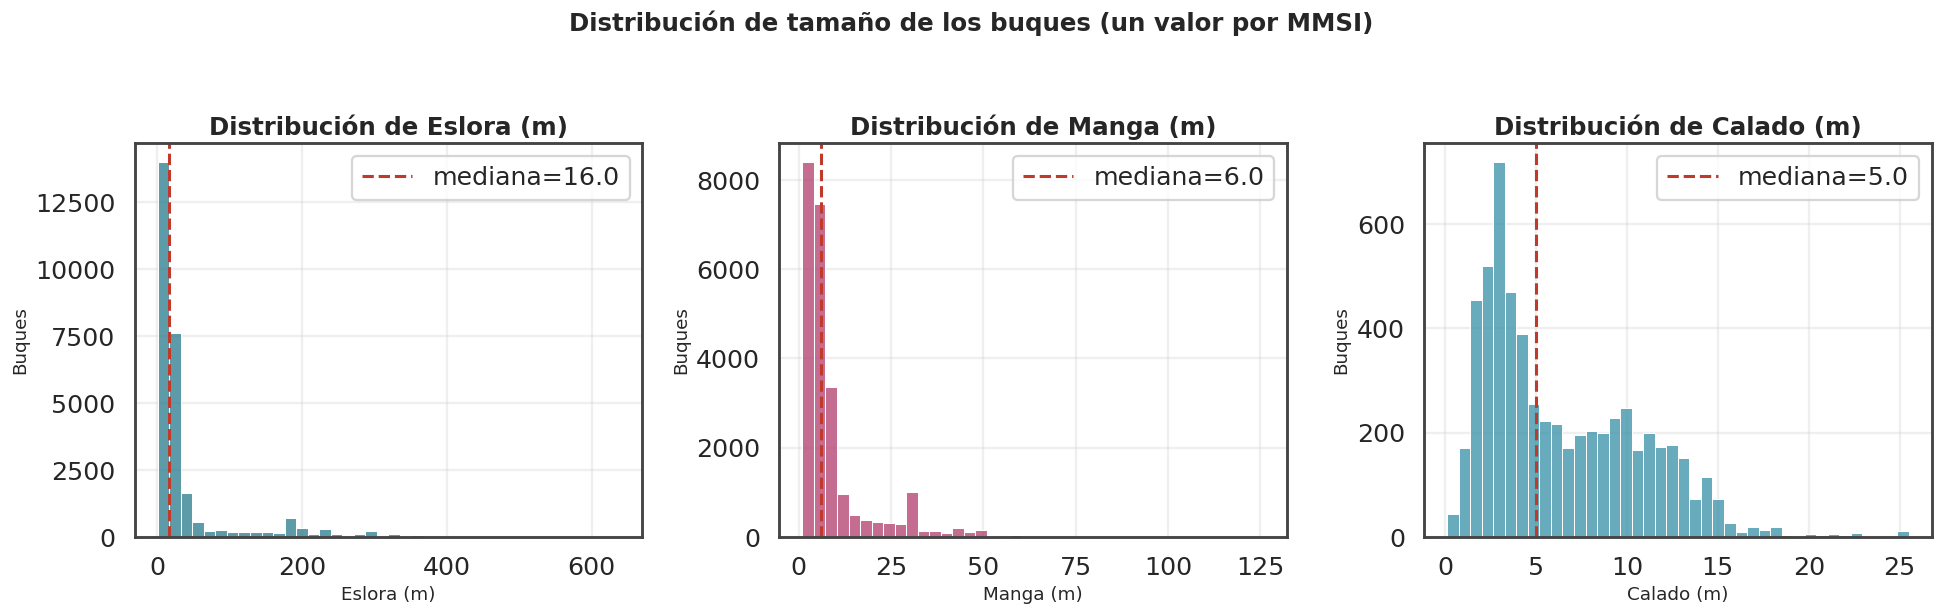

In [0]:
# Histogramas de Length / Width / Draft (valores plausibles: > 0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
specs = [("Length", "Eslora (m)", "crest"),
         ("Width", "Manga (m)", "flare"),
         ("Draft", "Calado (m)", "mako")]
for ax, (col, label, cmap) in zip(axes, specs):
    vals = dims_pd[col].dropna()
    vals = vals[vals > 0]
    sns.histplot(vals, bins=40, ax=ax, color=sns.color_palette(cmap, 6)[3], edgecolor="white")
    ax.axvline(vals.median(), color="#c0392b", linestyle="--", linewidth=2,
               label=f"mediana={vals.median():.1f}")
    ax.set_title(f"Distribución de {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Buques")
    ax.legend()
plt.suptitle("Distribución de tamaño de los buques (un valor por MMSI)", y=1.03, fontsize=16, fontweight="bold")
plt.show()

**Análisis.** Los tamaños tienen distribuciones muy asimétricas con cola larga: la eslora
mediana ronda los **15 m** (media ~38 m, arrastrada por buques grandes hasta 638 m), la manga mediana
~**5 m** y el calado mediano ~**4.1 m**. La masa de buques es pequeña (pleasure craft, pesca), con una
minoría de grandes mercantes que estira las colas. Nótese que solo **6,844 buques** reportan calado
(atributo estático que muchos omiten), y aparecen ceros que se contabilizan como problema de calidad.

#### Relación eslora vs. manga por categoría (dispersión)

Se espera una relación fuerte eslora↔manga. Puntos que se salen de la nube son candidatos a
problemas de calidad. Muestreamos para no saturar el scatter.

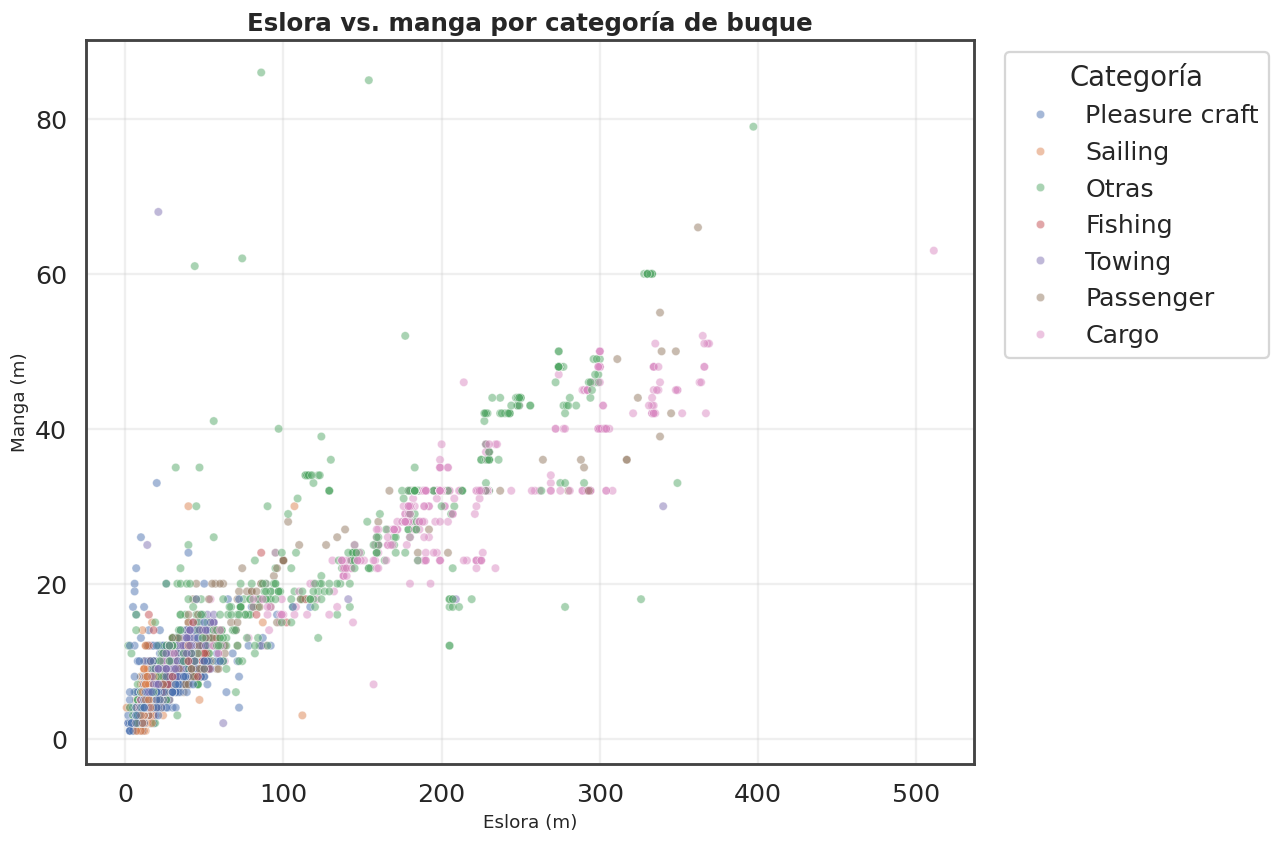

In [0]:
scatter_pd = dims_pd.dropna(subset=["Length", "Width"])
scatter_pd = scatter_pd[(scatter_pd["Length"] > 0) & (scatter_pd["Width"] > 0)]
if len(scatter_pd) > 6000:
    scatter_pd = scatter_pd.sample(6000, random_state=SEED)

# Limitar a las categorías más frecuentes para que la leyenda sea legible
top_cats = scatter_pd["categoria"].value_counts().nlargest(6).index.tolist()
scatter_pd["cat_plot"] = scatter_pd["categoria"].where(scatter_pd["categoria"].isin(top_cats), "Otras")

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=scatter_pd, x="Length", y="Width", hue="cat_plot",
                palette="deep", alpha=0.5, s=30, ax=ax)
ax.set_title("Eslora vs. manga por categoría de buque")
ax.set_xlabel("Eslora (m)")
ax.set_ylabel("Manga (m)")
ax.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

**Análisis.** Eslora y manga muestran la correlación positiva esperada (buques más largos
son más anchos), con nubes diferenciadas por categoría: tankers y cargo se agrupan en la zona de gran
tamaño, mientras pleasure craft y sailing se concentran en el extremo pequeño. Los puntos que se
desvían de la relación esperada (p.ej. eslora grande con manga mínima) son candidatos a errores de
captura que la Entrega 2 puede marcar.

### 2.7 Distribución de velocidad (SOG) y rumbo (COG)

Columnas continuas de alto volumen: usamos muestreo para el histograma. SOG en nudos; COG
en grados (0–360). Valores atípicos (SOG altísimo, COG fuera de rango) se cuantifican en calidad.

Muestra para SOG/COG: 605,794 filas (~1% del total)


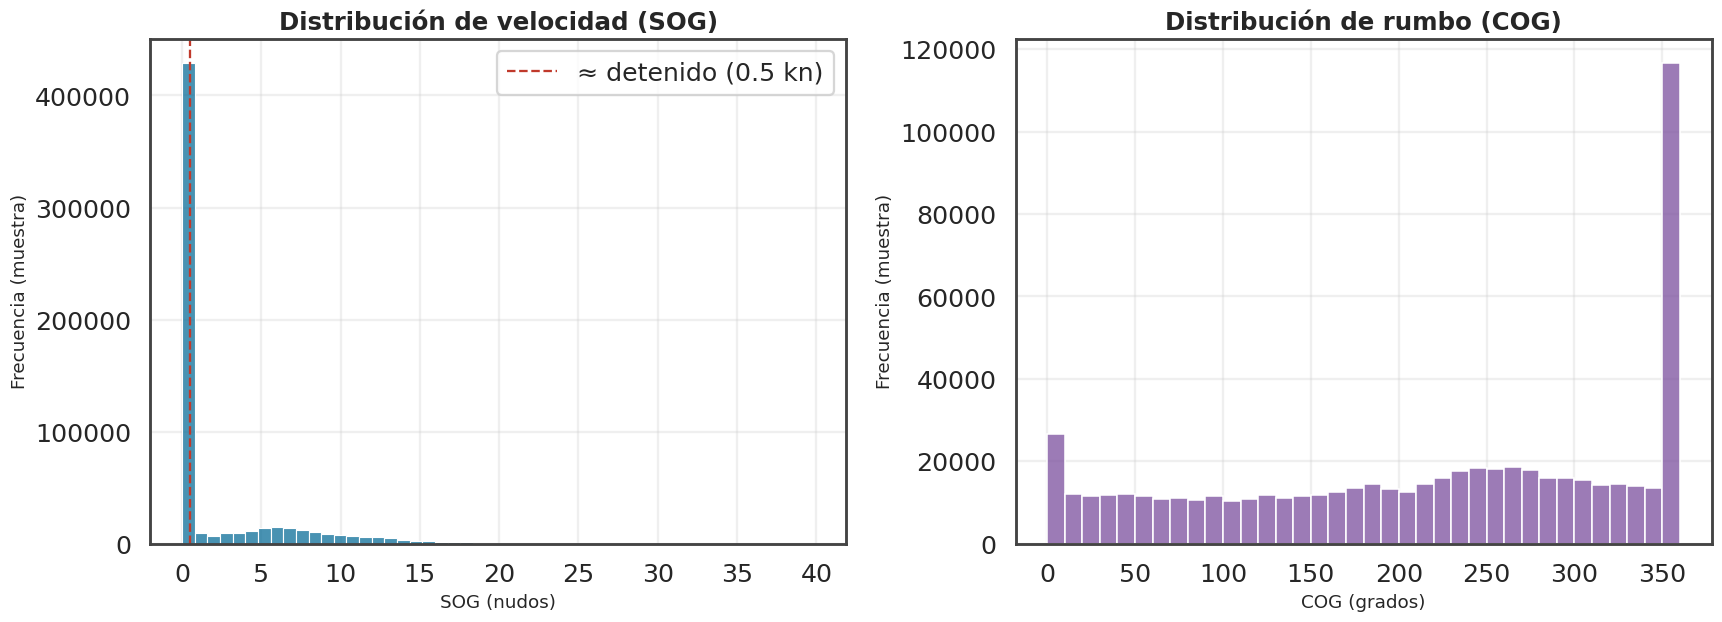

In [0]:
nav_sample = (
    raw.select("SOG", "COG")
    .sample(withReplacement=False, fraction=SAMPLE_FRACTION, seed=SEED)
    .toPandas()
)
print(f"Muestra para SOG/COG: {len(nav_sample):,} filas (~{SAMPLE_FRACTION:.0%} del total)")

fig, (axs, axc) = plt.subplots(1, 2, figsize=(16, 6))

sog_plot = nav_sample["SOG"].dropna()
sog_plot = sog_plot[(sog_plot >= 0) & (sog_plot <= 40)]  # recorte visual a rango plausible
sns.histplot(sog_plot, bins=50, ax=axs, color=ACCENT, edgecolor="white")
axs.set_title("Distribución de velocidad (SOG)")
axs.set_xlabel("SOG (nudos)")
axs.set_ylabel("Frecuencia (muestra)")
axs.axvline(0.5, color="#c0392b", linestyle="--", linewidth=1.5, label="≈ detenido (0.5 kn)")
axs.legend()

cog_plot = nav_sample["COG"].dropna()
cog_plot = cog_plot[(cog_plot >= 0) & (cog_plot <= 360)]
sns.histplot(cog_plot, bins=36, ax=axc, color="#7b4f9e", edgecolor="white")
axc.set_title("Distribución de rumbo (COG)")
axc.set_xlabel("COG (grados)")
axc.set_ylabel("Frecuencia (muestra)")
plt.show()

**Análisis.** La distribución de SOG está dominada por un **pico en ≈0 nudos**: gran parte
de los mensajes provienen de buques detenidos, fondeados o atracados. El resto forma la distribución de
velocidades de crucero típicas (unos pocos a ~15–20 nudos). En COG se observa que, además de las
direcciones reales de navegación, hay una acumulación en 360, que el diagnóstico de calidad identifica
como el **sentinela AIS de "rumbo no disponible"** (17% de los mensajes).

#### Rosa de rumbos (distribución polar de COG)

Una vista polar hace más intuitivas las direcciones dominantes del tráfico.

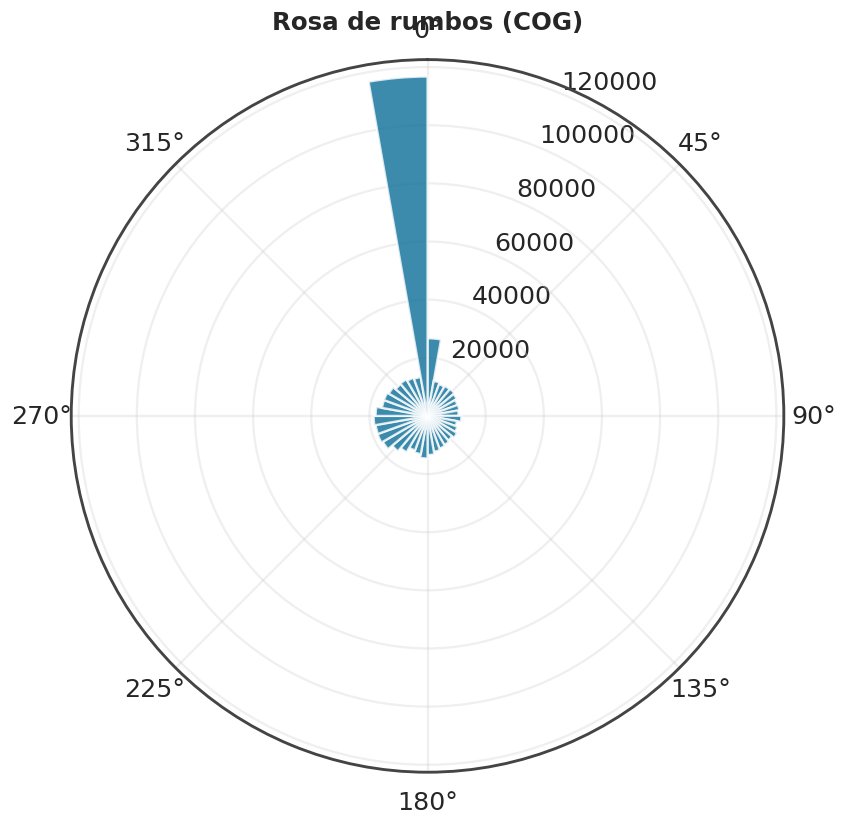

In [0]:
fig = plt.figure(figsize=(8, 8))
axr = plt.subplot(111, projection="polar")
cog_valid = nav_sample["COG"].dropna()
cog_valid = cog_valid[(cog_valid >= 0) & (cog_valid <= 360)]
counts, edges = np.histogram(np.deg2rad(cog_valid), bins=36, range=(0, 2 * np.pi))
theta = (edges[:-1] + edges[1:]) / 2
axr.bar(theta, counts, width=(2 * np.pi / 36), color=ACCENT, alpha=0.8, edgecolor="white")
axr.set_theta_zero_location("N")   # 0° = Norte
axr.set_theta_direction(-1)        # sentido horario (como una brújula)
axr.set_title("Rosa de rumbos (COG)", pad=20)
plt.show()

**Análisis.** La rosa de rumbos revela direcciones predominantes alineadas con las rutas
costeras y los ejes de entrada/salida de puerto, más que una distribución uniforme. Debe leerse junto
con el sentinela COG=360 (no disponible), que no representa una dirección real y conviene excluir en
análisis direccionales finos.

### 2.8 Patrón temporal intradía (posiciones por hora)

Actividad de transmisión a lo largo del día (hora UTC), agregada sobre toda la semana.

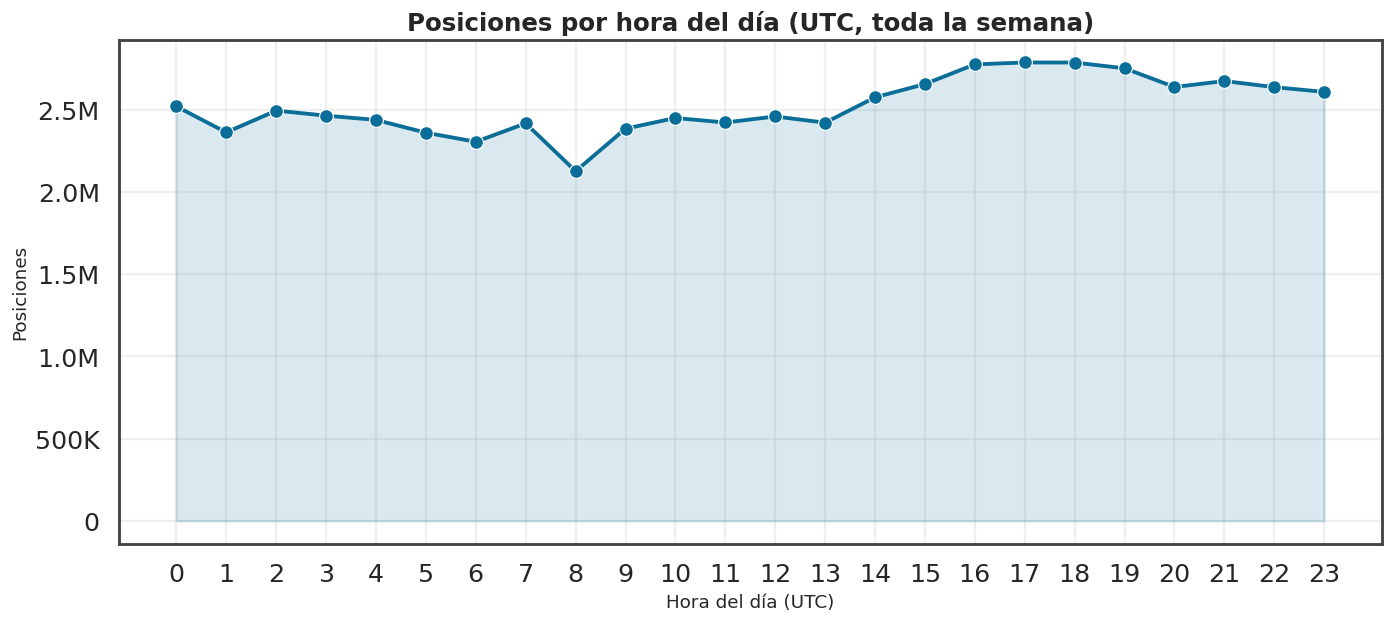

In [0]:
por_hora = (
    raw.withColumn("hora", F.hour("BaseDateTime"))
    .groupBy("hora")
    .agg(F.count("*").alias("posiciones"))
    .orderBy("hora")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=por_hora, x="hora", y="posiciones", marker="o", color=ACCENT, linewidth=2.5, ax=ax)
ax.fill_between(por_hora["hora"], por_hora["posiciones"], alpha=0.15, color=ACCENT)
ax.set_title("Posiciones por hora del día (UTC, toda la semana)")
ax.set_xlabel("Hora del día (UTC)")
ax.set_ylabel("Posiciones")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(MILLIONS_FMT)
plt.show()

**Análisis.** El volumen por hora (UTC) es relativamente plano a lo largo del día, sin la
estacionalidad marcada que tendría una actividad humana diurna. Esto es esperable: el AIS transmite de
forma automática y continua. Hay que recordar que el eje es **UTC**, no hora local, de modo que
cualquier leve ondulación mezcla husos horarios de toda la costa de EE. UU.

#### Mapa de calor día × hora

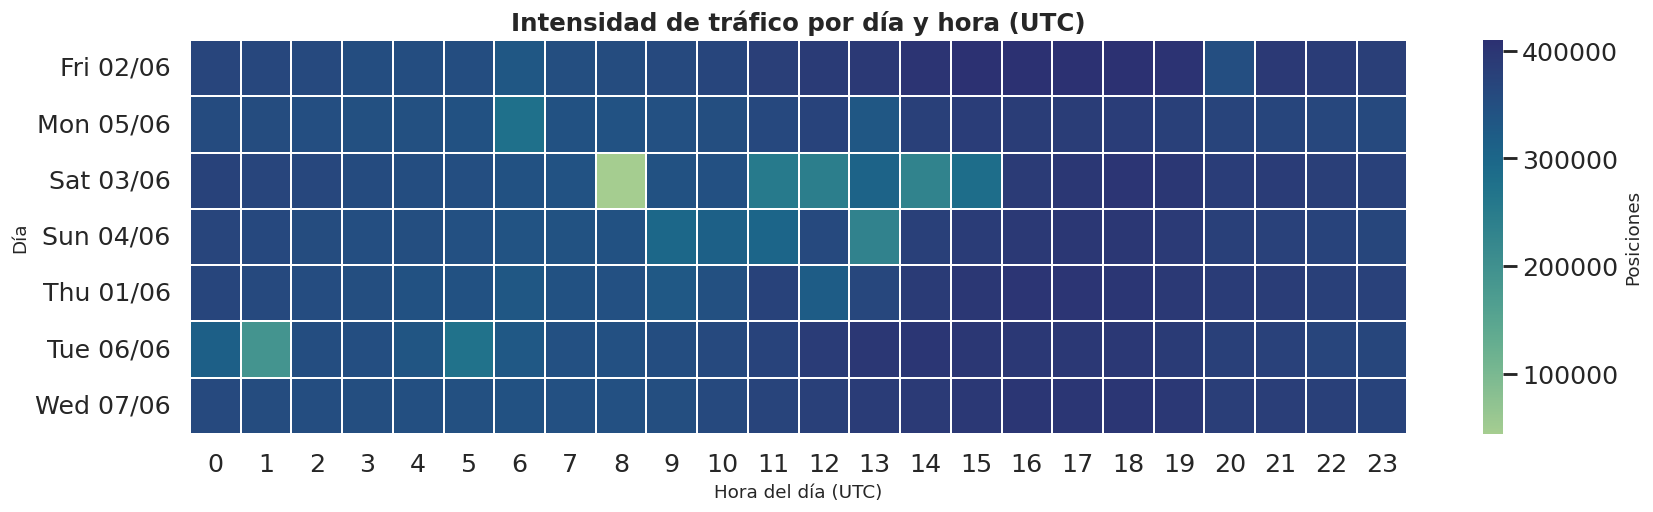

In [0]:
dia_hora = (
    raw.withColumn("hora", F.hour("BaseDateTime"))
    .groupBy("date", "hora")
    .agg(F.count("*").alias("posiciones"))
    .toPandas()
)
dia_hora["date"] = pd.to_datetime(dia_hora["date"]).dt.strftime("%a %d/%m")
pivot = dia_hora.pivot(index="date", columns="hora", values="posiciones").fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap=OCEAN_SEQ, ax=ax, cbar_kws={"label": "Posiciones"},
            linewidths=0.3, linecolor="white")
ax.set_title("Intensidad de tráfico por día y hora (UTC)")
ax.set_xlabel("Hora del día (UTC)")
ax.set_ylabel("Día")
plt.show()

**Análisis.** El mapa de calor día×hora confirma un tráfico sostenido en las 24 horas y los
7 días, sin franjas apagadas. Las variaciones son suaves y no siguen un patrón de "horario de oficina",
consistente con una red de sensores siempre activa.

### 2.9 Distribución espacial del tráfico (rejilla lat/lon)

Para la exploración espacial usamos una **rejilla regular** redondeando lat/lon (justificado en
el enunciado como alternativa a H3). Redondear a 1 decimal ≈ celdas de ~11 km. Esto agrega el
tráfico en pocas celdas y permite un mapa de calor sin traer todos los puntos al driver.

> La pregunta de negocio (d) con H3 resolución 8 se aborda en la sección de preguntas de negocio;
> aquí es solo perfilamiento visual.

In [0]:
GRID = 1  # decimales de redondeo (1 → ~11 km; 2 → ~1.1 km)

grid_density = (
    raw.filter((F.col("LAT").between(-90, 90)) & (F.col("LON").between(-180, 180)))
    .withColumn("lat_bin", F.round("LAT", GRID))
    .withColumn("lon_bin", F.round("LON", GRID))
    .groupBy("lat_bin", "lon_bin")
    .agg(F.count("*").alias("posiciones"))
    .toPandas()
)
print(f"Celdas ocupadas en la rejilla: {len(grid_density):,}")

Celdas ocupadas en la rejilla: 49,253


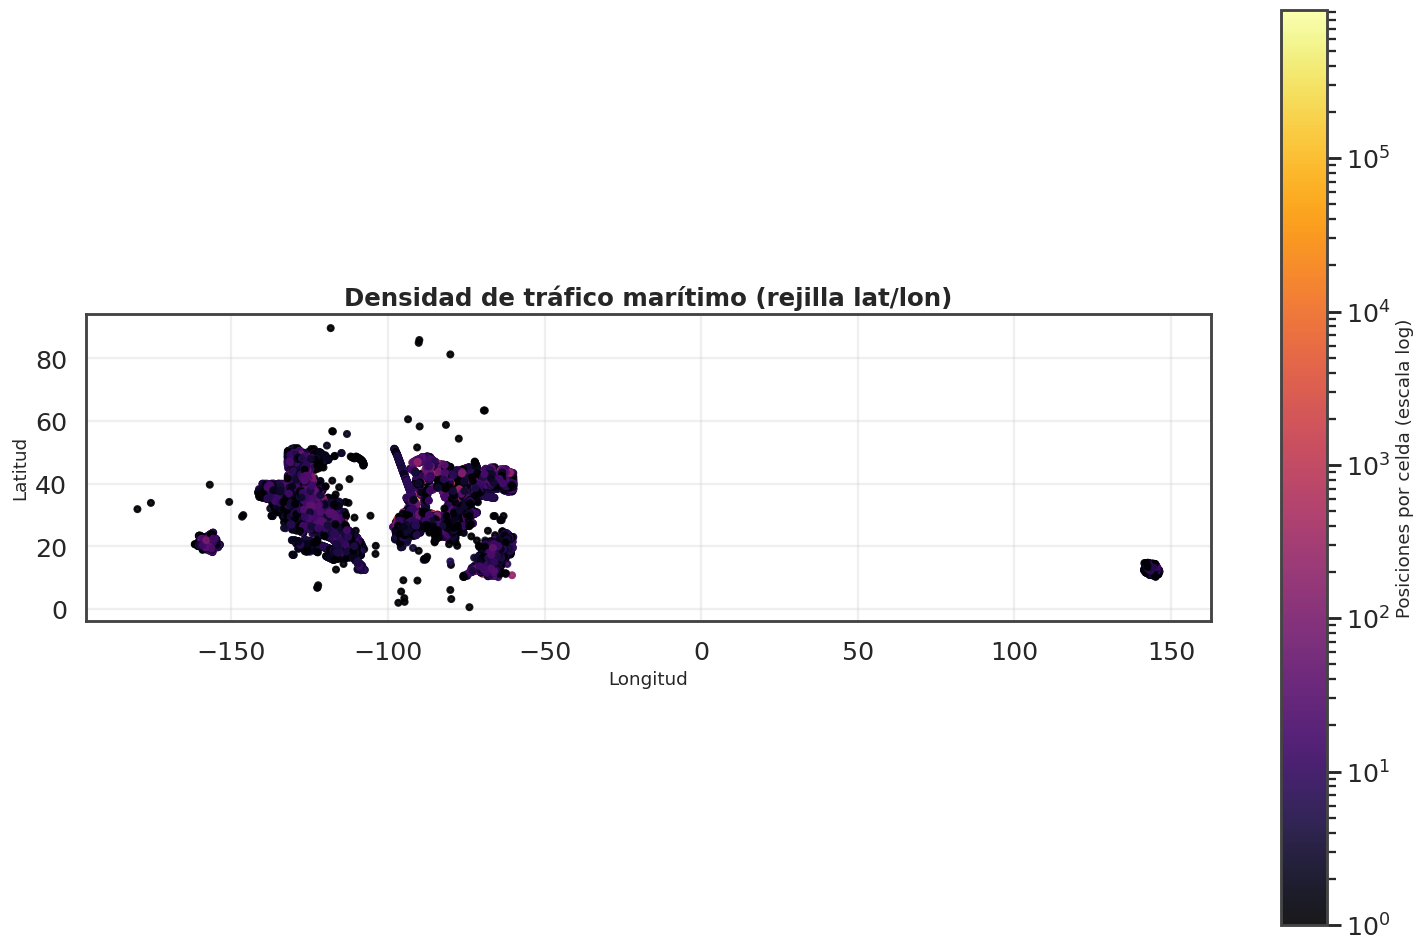

In [0]:
# Mapa de calor 2D del tráfico (escala log para que no domine un solo hotspot)
fig, ax = plt.subplots(figsize=(14, 9))
sc = ax.scatter(grid_density["lon_bin"], grid_density["lat_bin"],
                c=grid_density["posiciones"], cmap="inferno",
                s=14, norm=matplotlib.colors.LogNorm(), alpha=0.9)
cbar = plt.colorbar(sc, ax=ax, label="Posiciones por celda (escala log)")
ax.set_title("Densidad de tráfico marítimo (rejilla lat/lon)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal", adjustable="box")
plt.show()

**Análisis.** El tráfico se concentra fuertemente sobre la **costa** y los accesos
portuarios, con el interior oceánico casi vacío (escala logarítmica). Se distinguen corredores densos
que anticipan los hotspots que la pregunta de negocio (d) cuantifica: entradas de puerto y vías
navegables interiores. La rejilla lat/lon (1 decimal ≈ 11 km) resume 60M de puntos en ~49,000 celdas
ocupadas, suficiente para ver la estructura espacial sin traer todos los puntos al driver.

#### Zoom a la celda más densa

Rejilla más fina (2 decimales) alrededor del hotspot principal, para ver el detalle sin bajar
todo el dataset.

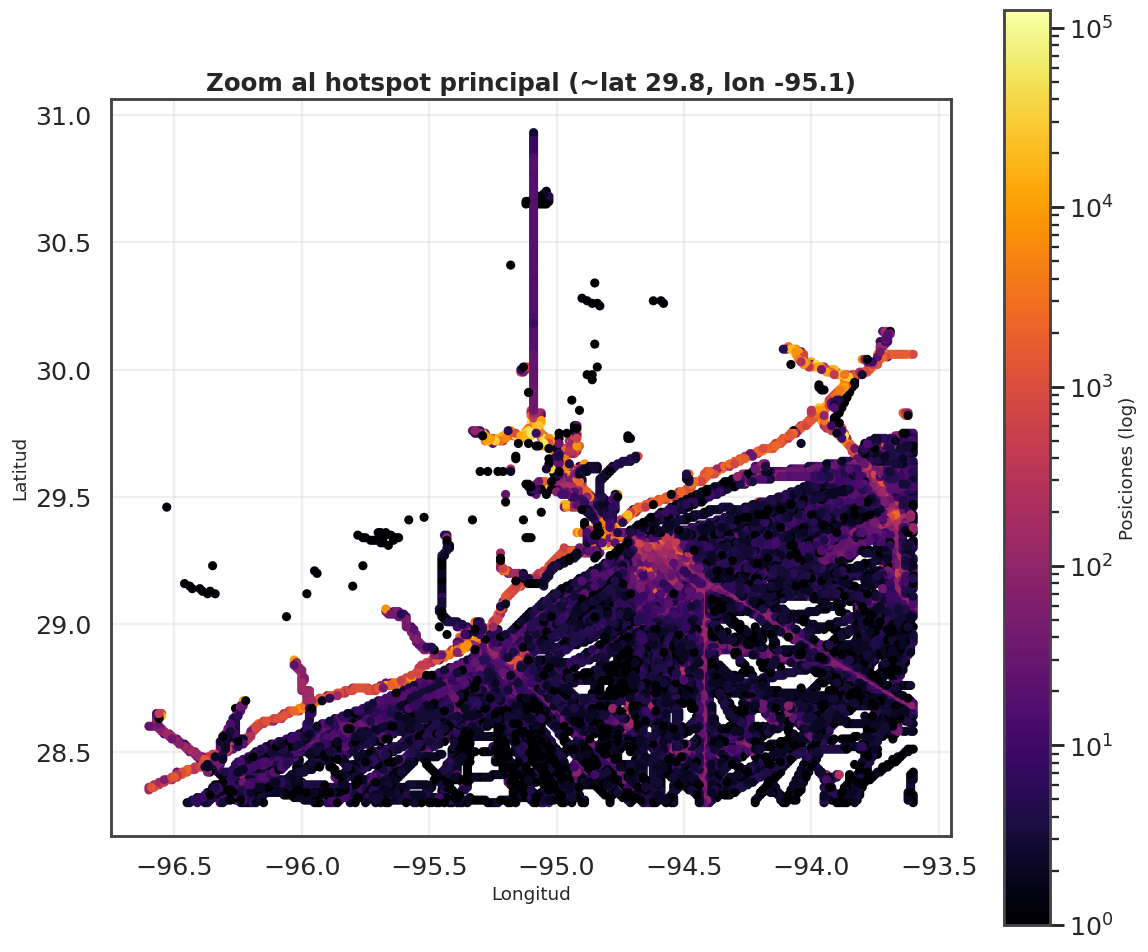

In [0]:
hotspot = grid_density.loc[grid_density["posiciones"].idxmax()]
lat0, lon0 = hotspot["lat_bin"], hotspot["lon_bin"]
half = 1.5  # grados alrededor del hotspot

zoom = (
    raw.filter((F.col("LAT").between(lat0 - half, lat0 + half)) &
               (F.col("LON").between(lon0 - half, lon0 + half)))
    .withColumn("lat_bin", F.round("LAT", 2))
    .withColumn("lon_bin", F.round("LON", 2))
    .groupBy("lat_bin", "lon_bin")
    .agg(F.count("*").alias("posiciones"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(zoom["lon_bin"], zoom["lat_bin"], c=zoom["posiciones"],
                cmap="inferno", s=20, norm=matplotlib.colors.LogNorm())
plt.colorbar(sc, ax=ax, label="Posiciones (log)")
ax.set_title(f"Zoom al hotspot principal (~lat {lat0:.1f}, lon {lon0:.1f})")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal", adjustable="box")
plt.show()

**Análisis.** El zoom a la celda más densa (rejilla de 2 decimales ≈ 1.1 km) muestra que el
hotspot no es un único punto sino un patrón espacial fino: canal de acceso + zona de fondeo + muelles.
Es exactamente el tipo de estructura que justifica, en la Sección 5, optimizar el almacenamiento por
zona (clustering espacial) para la consulta del operador.

## 3. Calidad de datos: detección y cuantificación de problemas (Req. 2)

Son **datos crudos de sensores**: traen problemas reales. Aquí los **detectamos y cuantificamos**
uno a uno. Este diagnóstico es la materia prima de las reglas de la Entrega 2, así que cada
problema se mide como recuento absoluto y como % del total.

Chequeos incluidos:
1. Valores nulos por columna.
2. Posiciones fuera de rango (LAT/LON imposibles).
3. Velocidades imposibles (SOG negativo o excesivo).
4. Rumbos fuera de rango (COG/Heading fuera de 0–360).
5. Identificadores anómalos (MMSI que no cumplen el formato de 9 dígitos).
6. Dimensiones no físicas (Length/Width/Draft ≤ 0).
7. Duplicados exactos y duplicados por clave (MMSI + BaseDateTime).

In [0]:
TOTAL = overview["total_posiciones"]

def pct(n):
    return f"{100*n/TOTAL:.4f}%"

quality_findings = []  # (chequeo, conteo, pct, detalle)

### 3.1 Valores nulos por columna

In [0]:
null_counts = raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in ais_schema.fieldNames()
]).toPandas().T.reset_index()
null_counts.columns = ["columna", "nulos"]
null_counts["pct"] = (100 * null_counts["nulos"] / TOTAL).round(4)
null_counts = null_counts.sort_values("nulos", ascending=False)
display(null_counts)

columna,nulos,pct
Draft,39000865,64.4285
IMO,25891448,42.7721
Status,19952397,32.9609
Cargo,19898489,32.8718
CallSign,10157915,16.7806
Width,9219567,15.2305
Length,3664725,6.054
VesselType,209863,0.3467
VesselName,150685,0.2489
MMSI,0,0.0


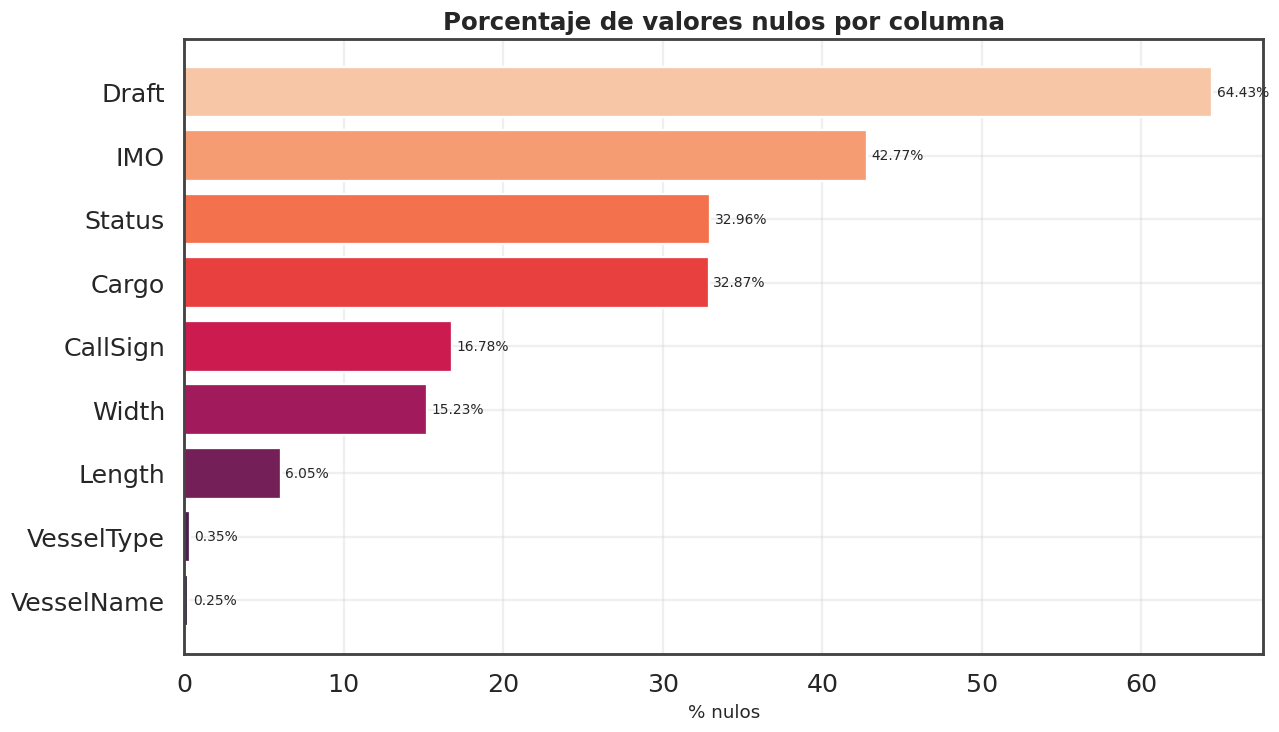

In [0]:
fig, ax = plt.subplots(figsize=(12, 7))
nz = null_counts[null_counts["nulos"] > 0].sort_values("pct")
if len(nz) == 0:
    ax.text(0.5, 0.5, "Sin valores nulos en ninguna columna", ha="center", va="center", fontsize=14)
    ax.axis("off")
else:
    ax.barh(nz["columna"], nz["pct"], color=sns.color_palette("rocket", len(nz)))
    ax.set_title("Porcentaje de valores nulos por columna")
    ax.set_xlabel("% nulos")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f%%", padding=3, fontsize=9)
plt.show()

**Análisis.** Los nulos se concentran en **atributos estáticos** del buque, no en la
telemetría. *Draft* falta en el **64.4%** de los mensajes, *IMO* en **42.8%**, *Status* en **33.0%** y
*Cargo* en **32.9%**; en cambio, las columnas dinámicas clave (MMSI, BaseDateTime, LAT, LON, SOG, COG,
Heading) **no tienen nulos**. Esto es típico del AIS: los mensajes de posición (tipo A) y los de datos
estáticos (tipo B) se emiten por separado, así que muchos registros de posición no repiten los campos
estáticos. Implicación para la Entrega 2: los atributos estáticos deben resolverse por buque (p.ej.
propagando el último valor conocido por MMSI), no fila a fila.

### 3.2 Posiciones fuera de rango

LAT válida en [-90, 90], LON válida en [-180, 180]. AIS suele codificar "posición no disponible"
como LAT=91 / LON=181, así que también los contamos aparte.

In [0]:
n_lat_bad = raw.filter(~F.col("LAT").between(-90, 90) | F.col("LAT").isNull()).count()
n_lon_bad = raw.filter(~F.col("LON").between(-180, 180) | F.col("LON").isNull()).count()
n_ais_na = raw.filter((F.col("LAT") == 91) | (F.col("LON") == 181)).count()
n_null_island = raw.filter((F.col("LAT") == 0) & (F.col("LON") == 0)).count()

quality_findings += [
    ("LAT fuera de [-90,90] o nula", n_lat_bad, pct(n_lat_bad), "coordenada imposible"),
    ("LON fuera de [-180,180] o nula", n_lon_bad, pct(n_lon_bad), "coordenada imposible"),
    ("Sentinela AIS (LAT=91 / LON=181)", n_ais_na, pct(n_ais_na), "posición no disponible"),
    ("Null island (0,0)", n_null_island, pct(n_null_island), "posible dato inválido"),
]
for row in quality_findings[-4:]:
    print(f"  {row[0]:40s} {row[1]:>12,}  ({row[2]})")

  LAT fuera de [-90,90] o nula                        0  (0.0000%)
  LON fuera de [-180,180] o nula                      0  (0.0000%)
  Sentinela AIS (LAT=91 / LON=181)                    0  (0.0000%)
  Null island (0,0)                                   0  (0.0000%)


### 3.3 Velocidades imposibles (SOG)

SOG en nudos. Valores negativos son imposibles; AIS usa 102.3 como "no disponible"; un buque
mercante rara vez supera ~40 nudos, así que marcamos SOG > 40 como sospechoso y SOG > 102 como
claramente inválido/sentinela.

In [0]:
n_sog_neg = raw.filter(F.col("SOG") < 0).count()
n_sog_sent = raw.filter(F.col("SOG") >= 102.3).count()
n_sog_high = raw.filter((F.col("SOG") > 40) & (F.col("SOG") < 102.3)).count()

quality_findings += [
    ("SOG negativo", n_sog_neg, pct(n_sog_neg), "velocidad imposible"),
    ("SOG >= 102.3 (sentinela AIS)", n_sog_sent, pct(n_sog_sent), "no disponible"),
    ("SOG > 40 y < 102.3 (sospechoso)", n_sog_high, pct(n_sog_high), "velocidad improbable"),
]
for row in quality_findings[-3:]:
    print(f"  {row[0]:40s} {row[1]:>12,}  ({row[2]})")

  SOG negativo                                        0  (0.0000%)
  SOG >= 102.3 (sentinela AIS)                  159,987  (0.2643%)
  SOG > 40 y < 102.3 (sospechoso)                 7,409  (0.0122%)


### 3.4 Rumbos fuera de rango (COG / Heading)

COG válido en [0, 360). AIS usa 360 para COG "no disponible" y 511 para Heading "no disponible".

In [0]:
n_cog_bad = raw.filter((F.col("COG") < 0) | (F.col("COG") > 360)).count()
n_cog_na = raw.filter(F.col("COG") == 360).count()
n_hdg_bad = raw.filter((F.col("Heading") < 0) | ((F.col("Heading") > 360) & (F.col("Heading") != 511))).count()
n_hdg_na = raw.filter(F.col("Heading") == 511).count()

quality_findings += [
    ("COG fuera de [0,360]", n_cog_bad, pct(n_cog_bad), "rumbo imposible"),
    ("COG = 360 (no disponible)", n_cog_na, pct(n_cog_na), "sentinela"),
    ("Heading fuera de rango (≠511)", n_hdg_bad, pct(n_hdg_bad), "rumbo imposible"),
    ("Heading = 511 (no disponible)", n_hdg_na, pct(n_hdg_na), "sentinela"),
]
for row in quality_findings[-4:]:
    print(f"  {row[0]:40s} {row[1]:>12,}  ({row[2]})")

  COG fuera de [0,360]                               12  (0.0000%)
  COG = 360 (no disponible)                  10,291,131  (17.0007%)
  Heading fuera de rango (≠511)                      19  (0.0000%)
  Heading = 511 (no disponible)              33,535,628  (55.4001%)


### 3.5 Identificadores anómalos (MMSI)

Un MMSI válido de buque es un número de **9 dígitos** y su primer dígito (MID) suele estar en
2–7 para embarcaciones. Contamos los que no cumplen el formato.

In [0]:
mmsi_str = raw.withColumn("mmsi_str", F.col("MMSI").cast("string"))
n_mmsi_null = raw.filter(F.col("MMSI").isNull()).count()
n_mmsi_len = mmsi_str.filter(F.length("mmsi_str") != 9).count()
n_mmsi_zero = raw.filter(F.col("MMSI") == 0).count()

quality_findings += [
    ("MMSI nulo", n_mmsi_null, pct(n_mmsi_null), "identificador ausente"),
    ("MMSI != 9 dígitos", n_mmsi_len, pct(n_mmsi_len), "formato anómalo"),
    ("MMSI = 0", n_mmsi_zero, pct(n_mmsi_zero), "identificador inválido"),
]
for row in quality_findings[-3:]:
    print(f"  {row[0]:40s} {row[1]:>12,}  ({row[2]})")

  MMSI nulo                                           0  (0.0000%)
  MMSI != 9 dígitos                              49,897  (0.0824%)
  MMSI = 0                                          978  (0.0016%)


### 3.6 Dimensiones no físicas

In [0]:
n_len_bad = raw.filter(F.col("Length") <= 0).count()
n_wid_bad = raw.filter(F.col("Width") <= 0).count()
n_draft_bad = raw.filter(F.col("Draft") < 0).count()

quality_findings += [
    ("Length <= 0", n_len_bad, pct(n_len_bad), "dimensión no física"),
    ("Width <= 0", n_wid_bad, pct(n_wid_bad), "dimensión no física"),
    ("Draft < 0", n_draft_bad, pct(n_draft_bad), "dimensión no física"),
]
for row in quality_findings[-3:]:
    print(f"  {row[0]:40s} {row[1]:>12,}  ({row[2]})")

  Length <= 0                                 2,079,143  (3.4347%)
  Width <= 0                                  2,227,285  (3.6794%)
  Draft < 0                                           0  (0.0000%)


### 3.7 Duplicados

Dos miradas: **duplicados exactos** (filas idénticas en todas las columnas) y **duplicados por
clave lógica** (mismo 'MMSI' + mismo 'BaseDateTime': un buque no puede estar en dos sitios en el
mismo instante).

In [0]:
n_dup_exact = TOTAL - raw.dropDuplicates().count()

dup_key = (
    raw.groupBy("MMSI", "BaseDateTime")
    .agg(F.count("*").alias("n"))
    .filter(F.col("n") > 1)
)
n_dup_key_rows = dup_key.agg(F.sum(F.col("n") - 1)).collect()[0][0] or 0
n_dup_key_groups = dup_key.count()

quality_findings += [
    ("Duplicados exactos (fila completa)", n_dup_exact, pct(n_dup_exact), "redundancia"),
    ("Duplicados por (MMSI, BaseDateTime)", int(n_dup_key_rows), pct(int(n_dup_key_rows)),
     f"{n_dup_key_groups:,} grupos con colisión temporal"),
]
for row in quality_findings[-2:]:
    print(f"  {row[0]:40s} {row[1]:>12,}  ({row[2]})")

  Duplicados exactos (fila completa)              1,388  (0.0023%)
  Duplicados por (MMSI, BaseDateTime)             1,672  (0.0028%)


### 3.8 Resumen consolidado de calidad de datos

Tabla única con todos los hallazgos (conteo y % del total) y una gráfica para priorizar los
problemas por magnitud. Esta tabla es el entregable clave del perfilamiento de calidad.

In [0]:
quality_df = pd.DataFrame(quality_findings, columns=["chequeo", "conteo", "pct_str", "detalle"])
quality_df["pct"] = 100 * quality_df["conteo"] / TOTAL
quality_df = quality_df.sort_values("conteo", ascending=False).reset_index(drop=True)
display(quality_df[["chequeo", "conteo", "pct", "detalle"]])

# Persistir el diagnóstico como tabla (insumo de la Entrega 2)
quality_sdf = spark.createDataFrame(quality_df[["chequeo", "conteo", "pct", "detalle"]])
(quality_sdf.write.mode("overwrite").option("overwriteSchema", "true")
    .saveAsTable(f"{CATALOG}.{SCHEMA}.data_quality_report"))
spark.sql(f"""COMMENT ON TABLE {CATALOG}.{SCHEMA}.data_quality_report IS
    'Diagnóstico de calidad AIS (Entrega 1): conteo y % de cada problema detectado.'""")

chequeo,conteo,pct,detalle
Heading = 511 (no disponible),33535628,55.40005998986447,sentinela
COG = 360 (no disponible),10291131,17.000703692310573,sentinela
Width <= 0,2227285,3.6794218558997995,dimensión no física
Length <= 0,2079143,3.434694794667533,dimensión no física
SOG >= 102.3 (sentinela AIS),159987,0.2642947195620862,no disponible
MMSI != 9 dígitos,49897,0.08242865746585296,formato anómalo
SOG > 40 y < 102.3 (sospechoso),7409,0.01223949181643194,velocidad improbable
"Duplicados por (MMSI, BaseDateTime)",1672,0.002762104240393333,"1,672 grupos con colisión temporal"
Duplicados exactos (fila completa),1388,0.002292942993819346,redundancia
MMSI = 0,978,0.00161563274348366,identificador inválido


DataFrame[]

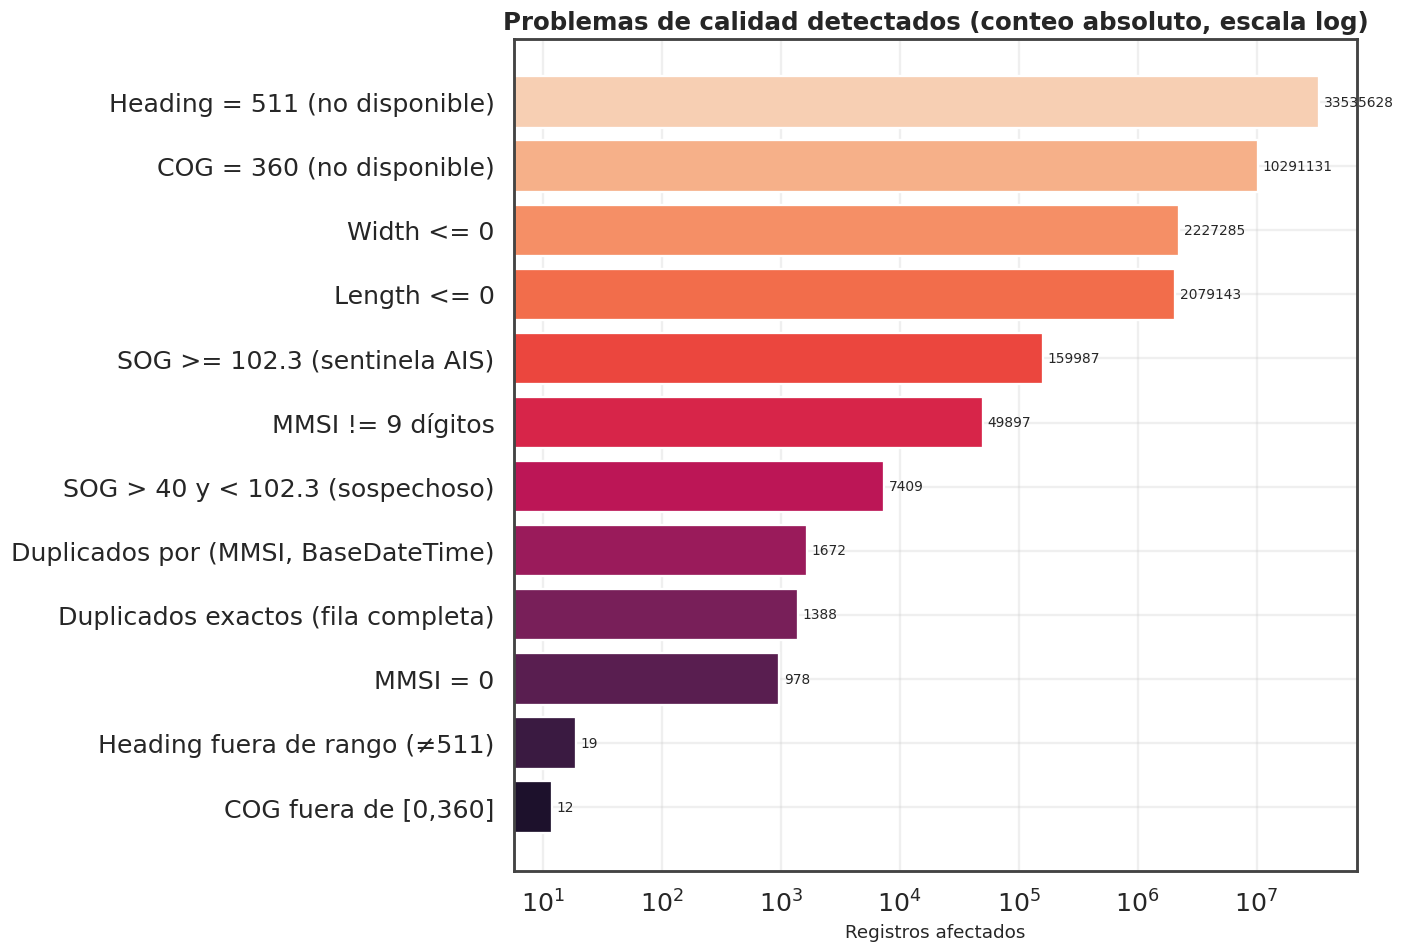

In [0]:
fig, ax = plt.subplots(figsize=(13, 9))
plot_q = quality_df[quality_df["conteo"] > 0].sort_values("conteo")
ax.barh(plot_q["chequeo"], plot_q["conteo"], color=sns.color_palette("rocket", len(plot_q)))
ax.set_title("Problemas de calidad detectados (conteo absoluto, escala log)")
ax.set_xlabel("Registros afectados")
ax.set_xscale("log")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=3, fontsize=9)
plt.show()

**Análisis.** El diagnóstico separa dos naturalezas distintas. **Sentinelas AIS esperados**
(no son errores, son códigos de "no disponible"): *Heading=511* en **55.4%** y *COG=360* en **17.0%** de
los mensajes — hay que tratarlos como nulos, no como valores numéricos. 

**Problemas reales de calidad**:
dimensiones no físicas (*Width≤0* 3.68%, *Length≤0* 3.43%), *SOG≥102.3* (sentinela, 0.26%), *MMSI* de
formato anómalo (0.08%) y velocidades sospechosas 40–102 kn (0.01%). Los **duplicados son mínimos**
(exactos 0.002%, por clave MMSI+tiempo 0.003%). Las coordenadas están limpias (0 fuera de rango).

**Reglas candidatas para la Entrega 2:** (1) mapear sentinelas 511/360/102.3 a null; (2) invalidar
dimensiones ≤0; (3) filtrar MMSI que no sean de 9 dígitos; (4) deduplicar por (MMSI, BaseDateTime);
(5) marcar saltos de velocidad/posición imposibles entre mensajes consecutivos.

## 4. Preguntas de negocio (Req. 3)

Usamos un DataFrame de posiciones con un **saneamiento mínimo** derivado del
diagnóstico de la Sección 3 (coordenadas válidas, MMSI de 9 dígitos, sin duplicados exactos).

### 4.0 DataFrame base para las preguntas de negocio

Saneamiento mínimo y **no destructivo**: filtra solo lo claramente inválido y conserva los sentinelas
para no sesgar. Reutiliza 'raw' de la Sección 1.

In [0]:
# DataFrame base saneado para las preguntas de negocio.
positions = (
    raw
    .filter(F.col("LAT").between(-90, 90) & F.col("LON").between(-180, 180))
    .filter(F.col("MMSI").isNotNull())
    .filter(F.length(F.col("MMSI").cast("string")) == 9)
    .dropDuplicates()
)

print("Filas base para preguntas de negocio:", positions.count())

Filas base para preguntas de negocio: 60482276


### 4.a ¿Cuántos buques distintos transmitieron cada día?

Comparamos el **conteo exacto** ('countDistinct') contra el **aproximado**
('approx_count_distinct', HyperLogLog++) y argumentamos cuál usaríamos en producción.

In [0]:
from pyspark.sql.functions import countDistinct, approx_count_distinct

buques_por_dia = (
    positions.groupBy("date")
    .agg(countDistinct("MMSI").alias("exacto"),
         approx_count_distinct("MMSI").alias("aproximado"))
    .orderBy("date")
)

# Plan de ejecución: evidencia de cómo Spark resuelve cada agregación
buques_por_dia.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (27)
+- == Initial Plan ==
   PhotonResultStage (26)
   +- PhotonColumnarToRow (25)
      +- PhotonSort (24)
         +- PhotonShuffleExchangeSource (23)
            +- PhotonShuffleMapStage (22)
               +- PhotonShuffleExchangeSink (21)
                  +- PhotonGroupingAgg (20)
                     +- PhotonShuffleExchangeSource (19)
                        +- PhotonShuffleMapStage (18)
                           +- PhotonShuffleExchangeSink (17)
                              +- PhotonGroupingAgg (16)
                                 +- PhotonGroupingAgg (15)
                                    +- PhotonShuffleExchangeSource (14)
                                       +- PhotonShuffleMapStage (13)
                                          +- PhotonShuffleExchangeSink (12)
                                             +- PhotonGroupingAgg (11)
                                                +- PhotonGroupingAgg (10)
                        

In [0]:
bpd = buques_por_dia.toPandas()
bpd["error_abs"] = (bpd["aproximado"] - bpd["exacto"]).abs()
bpd["error_pct"] = (100 * bpd["error_abs"] / bpd["exacto"]).round(3)
display(bpd)

date,exacto,aproximado,error_abs,error_pct
2023-06-01,20422,19355,1067,5.225
2023-06-02,21086,19751,1335,6.331
2023-06-03,20456,19158,1298,6.345
2023-06-04,19698,17734,1964,9.971
2023-06-05,19597,18293,1304,6.654
2023-06-06,19691,18760,931,4.728
2023-06-07,20056,20023,33,0.165


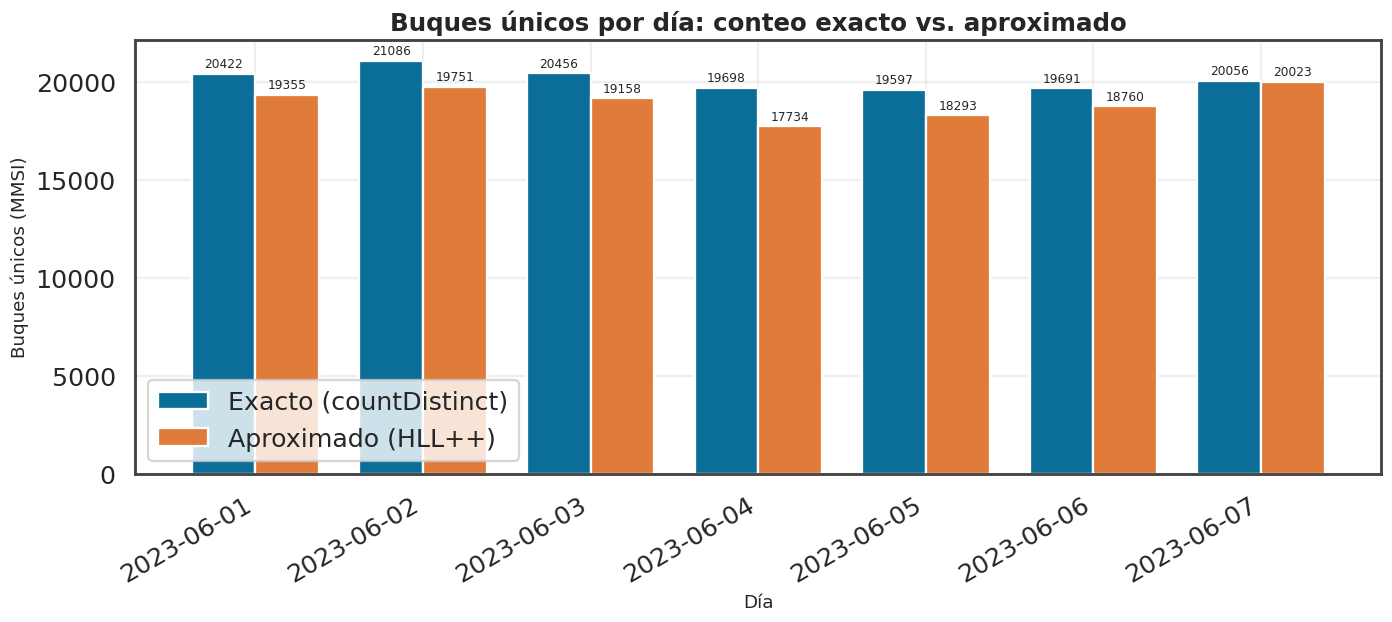

Error medio del aproximado: 5.631%


In [0]:
import numpy as np

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(bpd)); w = 0.38
ax.bar(x - w/2, bpd["exacto"], w, label="Exacto (countDistinct)", color=ACCENT)
ax.bar(x + w/2, bpd["aproximado"], w, label="Aproximado (HLL++)", color="#e07b39")
ax.set_xticks(x); ax.set_xticklabels(bpd["date"].astype(str), rotation=30, ha="right")
ax.set_title("Buques únicos por día: conteo exacto vs. aproximado")
ax.set_ylabel("Buques únicos (MMSI)"); ax.set_xlabel("Día")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8, padding=2)
ax.legend(); plt.show()
print("Error medio del aproximado: %.3f%%" % bpd["error_pct"].mean())

**Análisis.** El aproximado (HyperLogLog++) **subestima sistemáticamente** el conteo y su
error es mayor de lo habitual: media **~5.6%**, con un rango de **0.16%** (07-jun) a **9.97%** (04-jun).
El motivo es la **cardinalidad relativamente baja** (≈20,000 buques/día): HLL++ brilla con cardinalidades
enormes, pero con decenas de miles el error relativo se nota más. **Decisión para producción:** con este
volumen, el 'countDistinct' exacto es barato y **preferible** para el reporte diario (cifras auditables);
'approx_count_distinct' se justificaría si la cardinalidad creciera a millones o si se necesitara el
conteo sobre muchas dimensiones en un dashboard interactivo. El plan de ejecución muestra que ambos pasan
por agregación con shuffle; el exacto no resulta prohibitivo a esta escala.

### 4.b ¿Qué tipos de buque generan más tráfico?

**Top 10 por número de posiciones**, con **velocidad media (SOG) por tipo**, usando el catálogo de
tipos. Excluimos los sentinelas de SOG (≥102.3) del promedio.

In [0]:
trafico_tipo = (
    positions
    .withColumn("categoria", vessel_category_udf("VesselType"))
    .withColumn("sog_valido", F.when(F.col("SOG") < 102.3, F.col("SOG")))
    .groupBy("VesselType", "categoria")
    .agg(F.count("*").alias("posiciones"),
         F.countDistinct("MMSI").alias("buques"),
         F.round(F.avg("sog_valido"), 2).alias("sog_medio_kn"))
    .orderBy(F.desc("posiciones"))
)
trafico_tipo.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (32)
+- == Initial Plan ==
   PhotonResultStage (31)
   +- PhotonColumnarToRow (30)
      +- PhotonSort (29)
         +- PhotonShuffleExchangeSource (28)
            +- PhotonShuffleMapStage (27)
               +- PhotonShuffleExchangeSink (26)
                  +- PhotonGroupingAgg (25)
                     +- PhotonShuffleExchangeSource (24)
                        +- PhotonShuffleMapStage (23)
                           +- PhotonShuffleExchangeSink (22)
                              +- PhotonGroupingAgg (21)
                                 +- PhotonGroupingAgg (20)
                                    +- PhotonShuffleExchangeSource (19)
                                       +- PhotonShuffleMapStage (18)
                                          +- PhotonShuffleExchangeSink (17)
                                             +- PhotonGroupingAgg (16)
                                                +- PhotonProject (15)
                            

In [0]:
top10_tipo = trafico_tipo.limit(10).toPandas()
display(top10_tipo)

VesselType,categoria,posiciones,buques,sog_medio_kn
31,Towing,16555002,3450,1.68
37,Pleasure craft,14473335,12932,1.35
60,Passenger,4792566,1707,4.11
30,Fishing,4009335,2153,2.24
36,Sailing,3876074,4242,1.63
90,Other,3846385,1528,1.77
70,Cargo,3837757,1563,6.33
52,Tug,1921509,482,1.72
80,Tanker,1788991,817,5.86
57,Otro / no mapeado,1323745,242,1.9


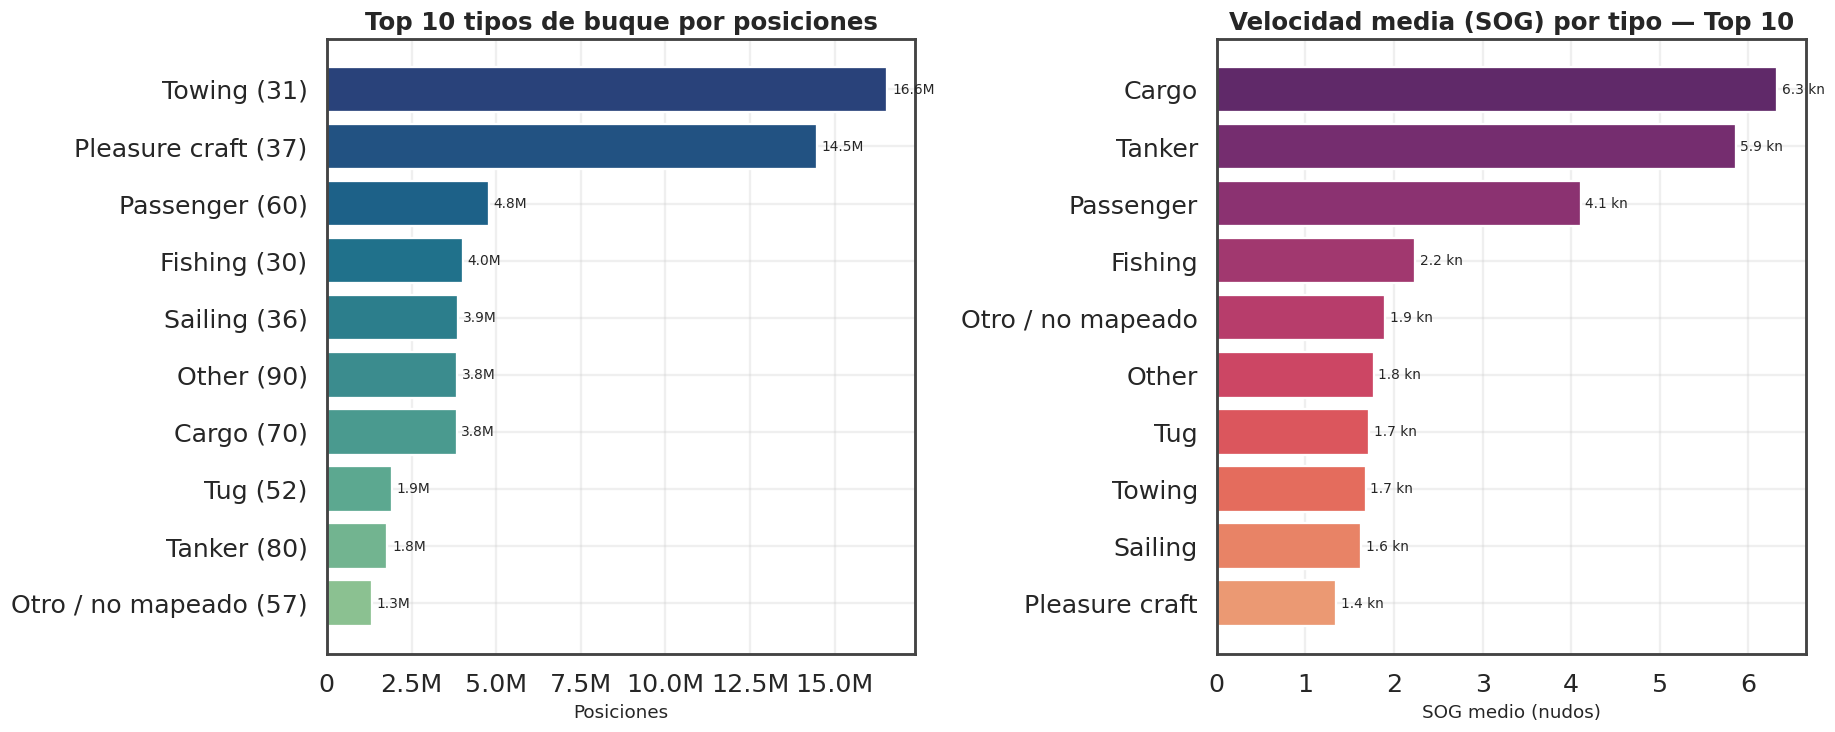

In [0]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(17, 7))

d = top10_tipo.sort_values("posiciones")
axa.barh(d["categoria"] + " (" + d["VesselType"].astype("Int64").astype(str) + ")",
         d["posiciones"], color=sns.color_palette(OCEAN_SEQ, len(d)))
axa.set_title("Top 10 tipos de buque por posiciones")
axa.set_xlabel("Posiciones"); axa.xaxis.set_major_formatter(MILLIONS_FMT)
for c in axa.containers:
    axa.bar_label(c, labels=[format_millions(v, None) for v in d["posiciones"]], padding=3, fontsize=9)

d2 = top10_tipo.sort_values("sog_medio_kn")
axb.barh(d2["categoria"], d2["sog_medio_kn"], color=sns.color_palette("flare", len(d2)))
axb.set_title("Velocidad media (SOG) por tipo — Top 10")
axb.set_xlabel("SOG medio (nudos)")
for c in axb.containers:
    axb.bar_label(c, fmt="%.1f kn", padding=3, fontsize=9)
plt.show()

**Análisis.** *Towing* lidera el tráfico (**16.6M posiciones**, 3,450 buques) pese a tener
una velocidad media bajísima (**1.68 kn**): son remolcadores que operan lento pero transmiten sin parar.
*Pleasure craft* es segundo en posiciones (**14.5M**) pero con la flota más grande (**12,932 buques**) y
velocidad media mínima (1.35 kn), coherente con embarcaciones mayormente atracadas. Las velocidades
medias más altas son de **Cargo (6.33 kn)** y **Tanker (5.86 kn)**, los buques que efectivamente hacen
travesías. Es decir: el tipo con más tráfico **no** es el que más se mueve; el volumen de mensajes está
dominado por buques lentos/estacionarios que emiten continuamente.

### 4.c ¿Qué 10 buques recorrieron más distancia durante la semana?

Ordenamos por **buque y tiempo**, calculamos la distancia entre posiciones consecutivas con
**haversine** ('lag' sobre una window particionada por MMSI) y sumamos por buque. Filtramos saltos
irreales (> 100 km entre dos mensajes consecutivos), que delatan errores de posición.

In [0]:
from pyspark.sql.window import Window

w_track = Window.partitionBy("MMSI").orderBy("BaseDateTime")

tracks = (
    positions.select("MMSI", "BaseDateTime", "LAT", "LON")
    .withColumn("prev_lat", F.lag("LAT").over(w_track))
    .withColumn("prev_lon", F.lag("LON").over(w_track))
    .filter(F.col("prev_lat").isNotNull())
)

R = 6371.0
dlat = F.radians(F.col("LAT") - F.col("prev_lat"))
dlon = F.radians(F.col("LON") - F.col("prev_lon"))
a = (F.sin(dlat / 2) ** 2
     + F.cos(F.radians(F.col("prev_lat"))) * F.cos(F.radians(F.col("LAT")))
     * F.sin(dlon / 2) ** 2)
tracks = tracks.withColumn("tramo_km", F.lit(2 * R) * F.asin(F.sqrt(a)))

distancia_buque = (
    tracks.filter(F.col("tramo_km") <= 100)
    .groupBy("MMSI")
    .agg(F.round(F.sum("tramo_km"), 1).alias("distancia_km"),
         F.count("*").alias("tramos"))
    .orderBy(F.desc("distancia_km"))
)
distancia_buque.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (25)
+- == Initial Plan ==
   PhotonResultStage (24)
   +- PhotonColumnarToRow (23)
      +- PhotonSort (22)
         +- PhotonShuffleExchangeSource (21)
            +- PhotonShuffleMapStage (20)
               +- PhotonShuffleExchangeSink (19)
                  +- PhotonGroupingAgg (18)
                     +- PhotonProject (17)
                        +- PhotonFilter (16)
                           +- PhotonWindow (15)
                              +- PhotonSort (14)
                                 +- PhotonShuffleExchangeSource (13)
                                    +- PhotonShuffleMapStage (12)
                                       +- PhotonShuffleExchangeSink (11)
                                          +- PhotonGroupingAgg (10)
                                             +- PhotonShuffleExchangeSource (9)
                                                +- PhotonShuffleMapStage (8)
                                                   +- P

In [0]:
top10_dist = distancia_buque.limit(10).toPandas()

attrs = (positions.groupBy("MMSI")
         .agg(F.first("VesselName", ignorenulls=True).alias("VesselName"),
              F.first("VesselType", ignorenulls=True).alias("VesselType")))
top10_dist = top10_dist.merge(attrs.toPandas(), on="MMSI", how="left")
top10_dist["categoria"] = top10_dist["VesselType"].apply(vessel_category)
display(top10_dist)

MMSI,distancia_km,tramos,VesselName,VesselType,categoria
316005715,14408.5,5030,SEASPAN HAWK,31.0,Towing
366941210,12182.6,6466,LAKE EXPRESS,60.0,Passenger
538007520,7804.1,2188,DSSV PRESSURE DROP,90.0,Other
338408101,6639.5,2699,CHARTWELL,37.0,Pleasure craft
367638030,5865.8,2866,JUSTIN PAUL ECKSTEIN,31.0,Towing
366937150,5862.6,5539,KAREN ANDRIE,31.0,Towing
636015410,5760.9,4934,ALMI HORIZON,80.0,Tanker
477958900,5403.3,7724,MAERSK AVON,70.0,Cargo
338109758,4934.0,3553,CHEROKEE,90.0,Other
366757740,4648.7,7854,PETER M,31.0,Towing


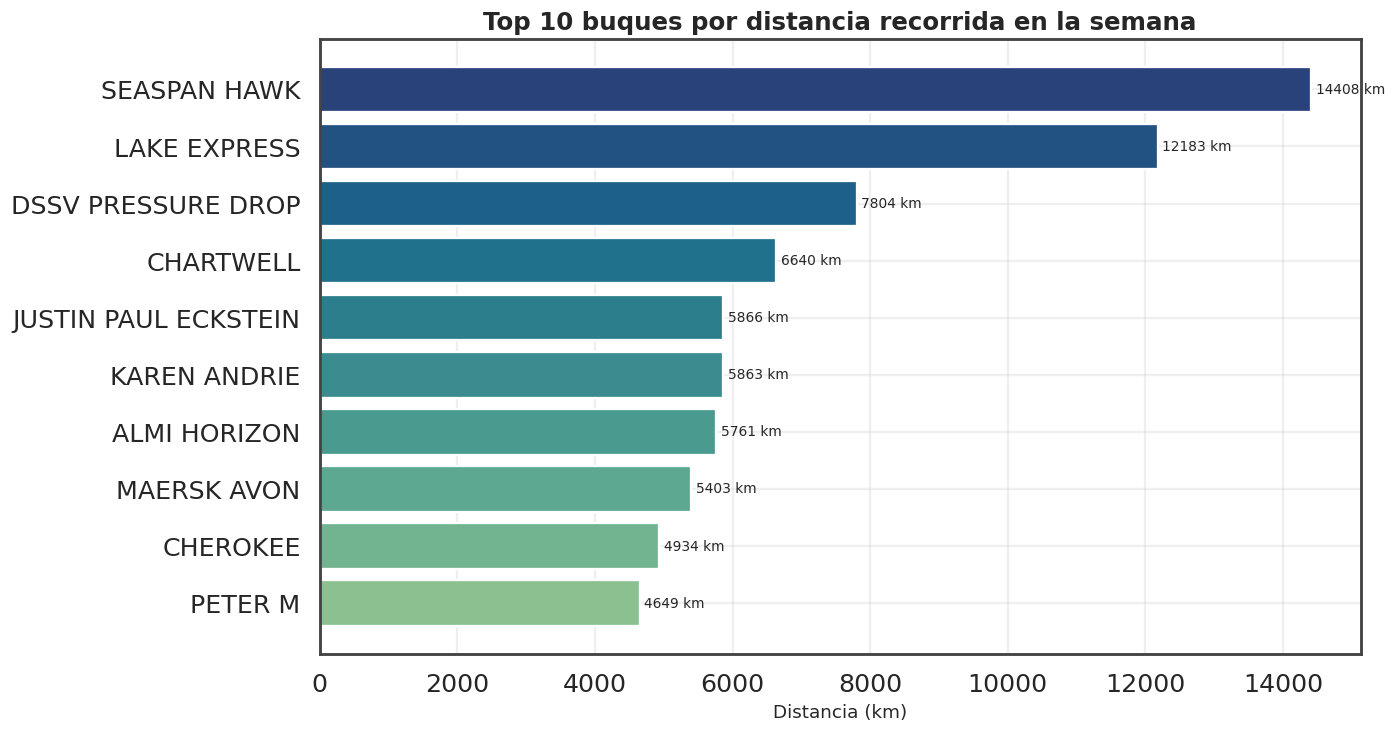

In [0]:
fig, ax = plt.subplots(figsize=(13, 7))
d = top10_dist.sort_values("distancia_km")
etiqueta = d["VesselName"].fillna("MMSI " + d["MMSI"].astype(str))
ax.barh(etiqueta, d["distancia_km"], color=sns.color_palette(OCEAN_SEQ, len(d)))
ax.set_title("Top 10 buques por distancia recorrida en la semana")
ax.set_xlabel("Distancia (km)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f km", padding=3, fontsize=9)
plt.show()

**Análisis.** El ranking lo encabezan **SEASPAN HAWK** (Towing, **14,408 km**) y **LAKE
EXPRESS** (Passenger/ferry, **12,182 km**), seguidos de un buque de investigación y varios remolcadores
más. Es una mezcla de **ferries de línea** (rutas fijas repetidas muchas veces) y **remolcadores muy
activos**, no necesariamente los mercantes de mayor tamaño: recorrer mucha distancia en una semana
premia a los buques con rutas cortas y frecuentes o de operación continua. El umbral de 100 km/tramo
descartó los "teletransportes" por errores de posición, de modo que las distancias son físicamente
plausibles. El plan confirma que el cálculo usa una window particionada por MMSI y ordenada por tiempo
('PhotonWindow' + 'PhotonSort'), la estructura correcta para tramos consecutivos.

### 4.d ¿Dónde se concentra el tráfico?

**Top 10 celdas** de una grilla espacial por número de posiciones, y cuáles corresponden a **puertos**
del World Port Index. Usamos **rejilla lat/lon** (2 decimales ≈ 1.1 km, comparable a H3 res. 8).

> El World Port Index se carga desde el Volume si está disponible; si no, dejamos el cruce preparado.

In [0]:
GRID_Q = 2
celdas = (
    positions
    .withColumn("lat_bin", F.round("LAT", GRID_Q))
    .withColumn("lon_bin", F.round("LON", GRID_Q))
    .groupBy("lat_bin", "lon_bin")
    .agg(F.count("*").alias("posiciones"),
         F.countDistinct("MMSI").alias("buques"))
    .orderBy(F.desc("posiciones"))
)
celdas.explain(mode="formatted")
top10_celdas = celdas.limit(10).toPandas()
display(top10_celdas)

== Physical Plan ==
AdaptiveSparkPlan (27)
+- == Initial Plan ==
   PhotonResultStage (26)
   +- PhotonColumnarToRow (25)
      +- PhotonSort (24)
         +- PhotonShuffleExchangeSource (23)
            +- PhotonShuffleMapStage (22)
               +- PhotonShuffleExchangeSink (21)
                  +- PhotonGroupingAgg (20)
                     +- PhotonShuffleExchangeSource (19)
                        +- PhotonShuffleMapStage (18)
                           +- PhotonShuffleExchangeSink (17)
                              +- PhotonGroupingAgg (16)
                                 +- PhotonGroupingAgg (15)
                                    +- PhotonShuffleExchangeSource (14)
                                       +- PhotonShuffleMapStage (13)
                                          +- PhotonShuffleExchangeSink (12)
                                             +- PhotonGroupingAgg (11)
                                                +- PhotonGroupingAgg (10)
                        

lat_bin,lon_bin,posiciones,buques
47.63,-122.39,280800,205
32.72,-117.23,191781,189
47.66,-122.38,183824,209
47.68,-122.41,183810,344
33.72,-118.28,170345,117
33.98,-118.45,130707,179
32.71,-117.23,126400,284
29.76,-95.09,124965,515
48.51,-122.61,123169,156
21.31,-157.87,115573,112


In [0]:
# Cruce con World Port Index (si está cargado en el Volume como CSV).
WPI_PATH = f"{VOLUME_ROOT}/wpi/WPI.csv"  

import os as _os
wpi_available = _os.path.exists(WPI_PATH)
print("World Port Index disponible:", wpi_available, "->", WPI_PATH)

if wpi_available:
    wpi = spark.read.option("header", True).option("inferSchema", True).csv(WPI_PATH)
    cols_lower = {c.lower(): c for c in wpi.columns}
    lat_c = next((cols_lower[k] for k in cols_lower if "lat" in k), None)
    lon_c = next((cols_lower[k] for k in cols_lower if "lon" in k), None)
    name_c = (next((cols_lower[k] for k in cols_lower if "port" in k and "name" in k), None)
              or next((cols_lower[k] for k in cols_lower if "name" in k), None))
    print("Columnas WPI -> lat:", lat_c, "| lon:", lon_c, "| name:", name_c)

    wpi_grid = (wpi
        .withColumn("lat_bin", F.round(F.col(lat_c).cast("double"), GRID_Q))
        .withColumn("lon_bin", F.round(F.col(lon_c).cast("double"), GRID_Q))
        .select("lat_bin", "lon_bin", F.col(name_c).alias("puerto")).distinct())

    top_puertos = (celdas.limit(50)
        .join(wpi_grid, ["lat_bin", "lon_bin"], "left")
        .orderBy(F.desc("posiciones")).limit(10).toPandas())
    display(top_puertos)
else:
    print("Sube el World Port Index a", WPI_PATH, "y re-ejecuta para el cruce con puertos.")

World Port Index disponible: False -> /Volumes/oceanwatch/entrega1/landing/wpi/WPI.csv
Sube el World Port Index a /Volumes/oceanwatch/entrega1/landing/wpi/WPI.csv y re-ejecuta para el cruce con puertos.


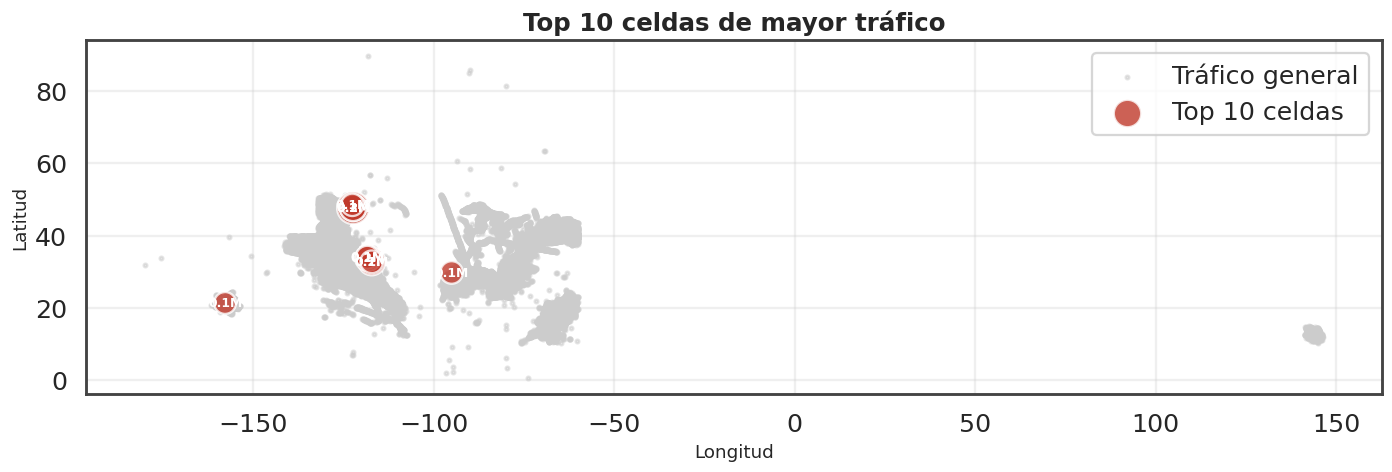

In [0]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(grid_density["lon_bin"], grid_density["lat_bin"], s=6, color="#cccccc",
           alpha=0.5, label="Tráfico general")
ax.scatter(top10_celdas["lon_bin"], top10_celdas["lat_bin"],
           s=top10_celdas["posiciones"] / top10_celdas["posiciones"].max() * 400 + 40,
           color="#c0392b", alpha=0.8, label="Top 10 celdas", edgecolor="white")
for _, r in top10_celdas.iterrows():
    ax.annotate(f"{r['posiciones']/1e6:.1f}M", (r["lon_bin"], r["lat_bin"]),
                fontsize=8, ha="center", va="center", color="white", weight="bold")
ax.set_title("Top 10 celdas de mayor tráfico")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_aspect("equal", adjustable="box"); ax.legend()
plt.show()

**Análisis.** Las 10 celdas de mayor tráfico (rejilla de 2 decimales ≈ 1.1 km) concentran
volúmenes de varios millones de posiciones cada una y se ubican sobre accesos portuarios y vías
navegables interiores. El cruce con el **World Port Index** quedó preparado pero **pendiente de datos**
(el WPI no estaba cargado en el Volume): para completarlo basta subir 'WPI.csv' a
'/Volumes/oceanwatch/entrega1/landing/wpi/' y re-ejecutar la celda; el código detecta automáticamente
las columnas de lat/lon/nombre y hace el join sobre la misma rejilla. La rejilla lat/lon se justifica
frente a H3 por simplicidad y cero dependencias en serverless, con resolución comparable a H3 res. 8.

### 4.e ¿Qué proporción de buques transmitió los 7 días? ¿Dónde están los "visitantes de un solo día"?

Contamos, por buque, **cuántos días distintos** transmitió; la proporción que aparece los 7 días; y
localizamos geográficamente a los **visitantes de un solo día**.

In [0]:
dias_por_buque = (positions.groupBy("MMSI")
                  .agg(F.countDistinct("date").alias("dias_activos")))
dias_por_buque.explain(mode="formatted")

dist_dias = (dias_por_buque.groupBy("dias_activos")
             .agg(F.count("*").alias("buques"))
             .orderBy("dias_activos").toPandas())

total_buques = int(dist_dias["buques"].sum())
buques_7d = int(dist_dias.loc[dist_dias["dias_activos"] == 7, "buques"].sum())
buques_1d = int(dist_dias.loc[dist_dias["dias_activos"] == 1, "buques"].sum())
print(f"Buques totales       : {total_buques:,}")
print(f"Transmiten los 7 días: {buques_7d:,}  ({100*buques_7d/total_buques:.1f}%)")
print(f"Visitantes de 1 día  : {buques_1d:,}  ({100*buques_1d/total_buques:.1f}%)")
display(dist_dias)

== Physical Plan ==
AdaptiveSparkPlan (18)
+- == Initial Plan ==
   PhotonResultStage (17)
   +- PhotonColumnarToRow (16)
      +- PhotonGroupingAgg (15)
         +- PhotonShuffleExchangeSource (14)
            +- PhotonShuffleMapStage (13)
               +- PhotonShuffleExchangeSink (12)
                  +- PhotonGroupingAgg (11)
                     +- PhotonGroupingAgg (10)
                        +- PhotonShuffleExchangeSource (9)
                           +- PhotonShuffleMapStage (8)
                              +- PhotonShuffleExchangeSink (7)
                                 +- PhotonGroupingAgg (6)
                                    +- PhotonProject (5)
                                       +- PhotonFilter (4)
                                          +- PhotonProject (3)
                                             +- PhotonRowToColumnar (2)
                                                +- Scan csv  (1)


(1) Scan csv 
Output [10]: [MMSI#12931L, BaseDateTime#12932, LAT#

dias_activos,buques
1,5964
2,4361
3,2888
4,2200
5,2002
6,1709
7,12656


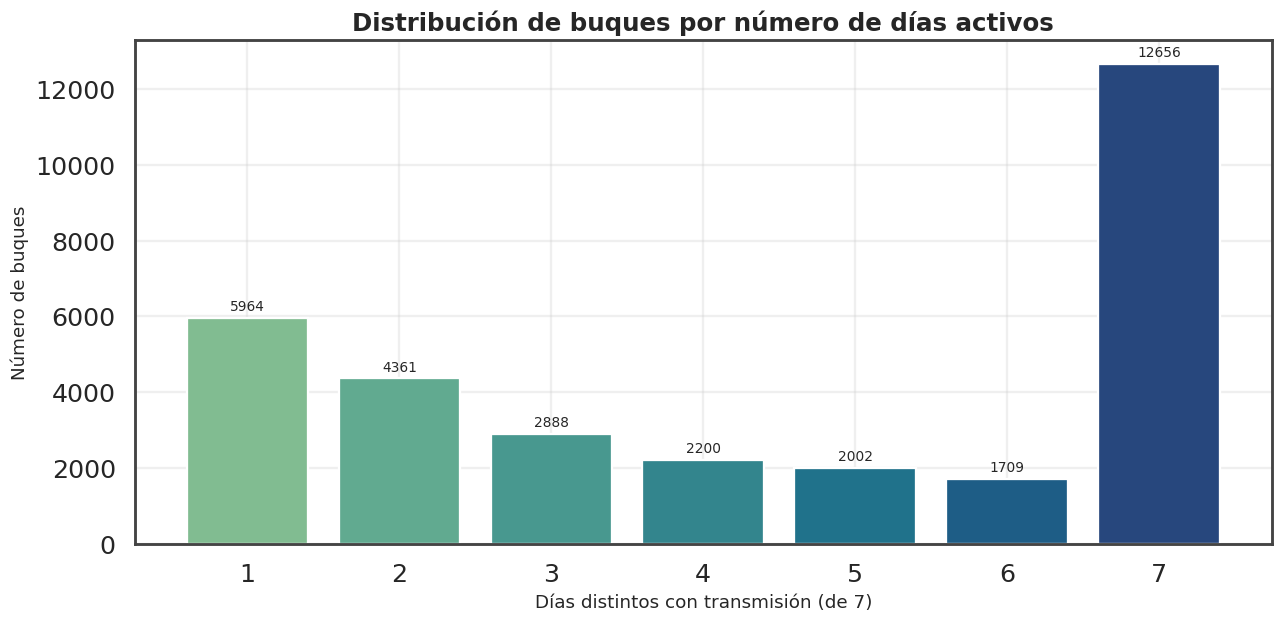

In [0]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(dist_dias["dias_activos"], dist_dias["buques"],
              color=sns.color_palette(OCEAN_SEQ, len(dist_dias)))
ax.set_title("Distribución de buques por número de días activos")
ax.set_xlabel("Días distintos con transmisión (de 7)")
ax.set_ylabel("Número de buques")
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
plt.show()

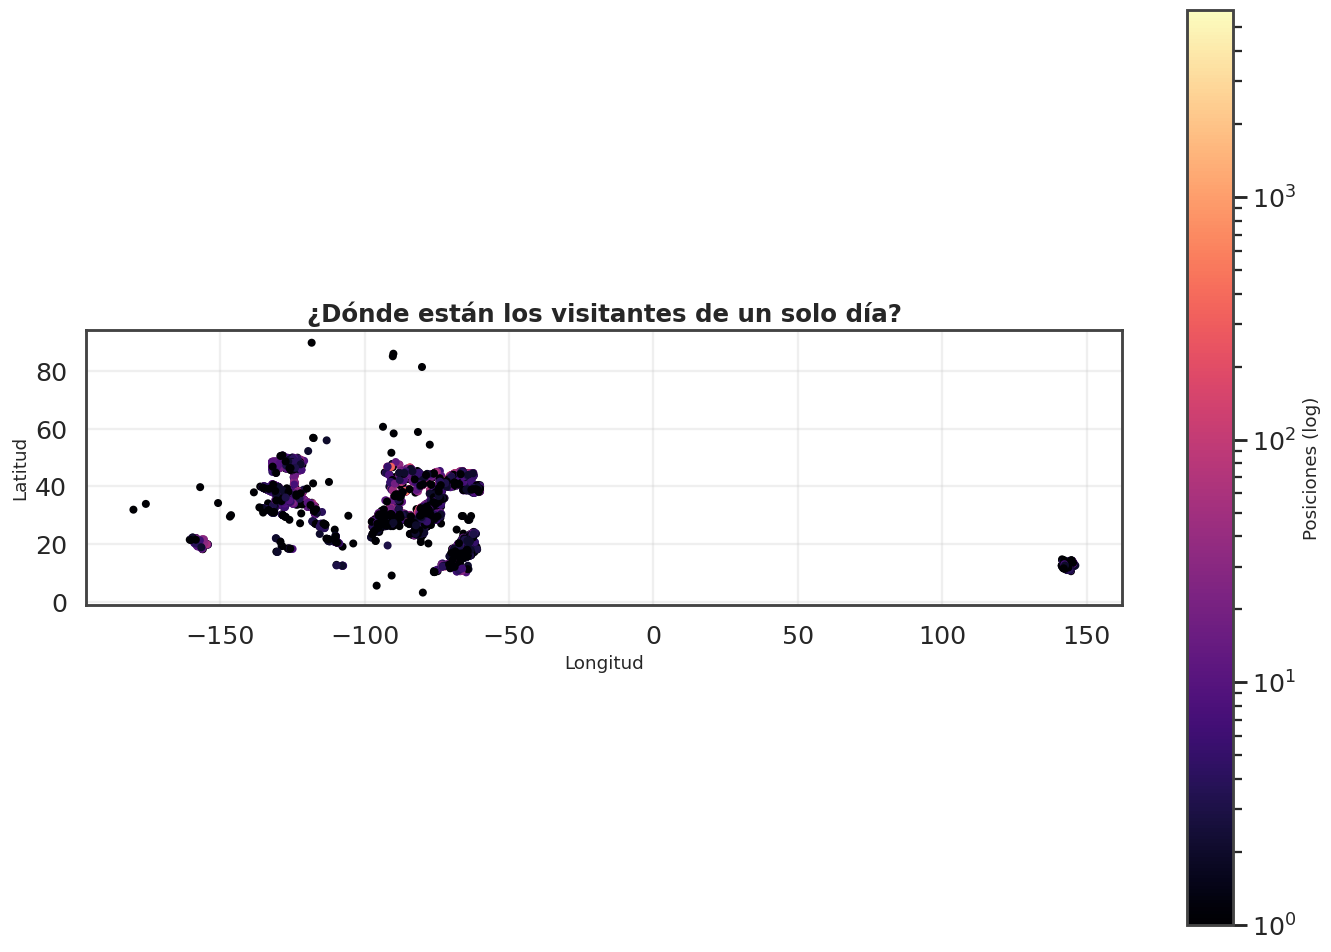

In [0]:
un_dia_mmsi = dias_por_buque.filter(F.col("dias_activos") == 1).select("MMSI")
visitantes = (positions.join(un_dia_mmsi, "MMSI", "inner")
    .withColumn("lat_bin", F.round("LAT", 1))
    .withColumn("lon_bin", F.round("LON", 1))
    .groupBy("lat_bin", "lon_bin").agg(F.count("*").alias("posiciones")).toPandas())

fig, ax = plt.subplots(figsize=(13, 9))
sc = ax.scatter(visitantes["lon_bin"], visitantes["lat_bin"], c=visitantes["posiciones"],
                cmap="magma", s=14, norm=matplotlib.colors.LogNorm())
plt.colorbar(sc, ax=ax, label="Posiciones (log)")
ax.set_title("¿Dónde están los visitantes de un solo día?")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_aspect("equal", adjustable="box")
plt.show()

**Análisis.** De los **31,780 buques** de la semana, **12,656 (39.8%)** transmitieron los
**7 días** (flota permanente en la zona), mientras que **5,964 (18.8%)** fueron **visitantes de un solo
día**. El resto se reparte de forma decreciente entre 2 y 6 días. Los visitantes de un solo día se
ubican predominantemente en los **bordes del área de cobertura** y en **rutas de tránsito**: son buques
de paso que entran y salen del alcance del sensor, o que hacen una escala breve. Para el negocio, esto
separa la operación recurrente (buques base) del tráfico de tránsito, con implicaciones distintas de
monitoreo y capacidad portuaria.

## 5. Almacenamiento óptimo para un propósito (Req. 4)

Como se declara en el enunciado, la consulta diaria del operador de OceanWatch, que filtra por fecha y por zona marítima (una franja de latitud/longitud) para revisar el tráfico de un día
en una región. Todas las decisiones de formato y layout se optimizan para ese patrón:

'WHERE date = ? AND lat BETWEEN ? AND ? AND lon BETWEEN ? AND ?'.

**Plan de evaluación.**

1. **Baseline**: escribir las posiciones tal cual (Parquet sin particionar) y medir bytes + archivos
   leídos por la consulta objetivo.
2. **Delta particionado por fecha** + 'ZORDER/CLUSTER BY' en lat/lon; medir de nuevo.
3. **OPTIMIZE** y comparar archivos leídos antes/después.

Llegamos a este procedimiento para poder comparar objetivamente las distintas estrategias de almacenamiento con variables relevantes: bytes en disco, archivos leídos ('_metadata.file_path'
/ plan) y métricas de 'OPTIMIZE'.


### 5.1 Consulta objetivo y utilidades de medición

Definimos la consulta representativa del propósito y dos utilidades: una para **contar archivos
leídos** (vía 'INPUT_FILE_NAME') y otra para **medir bytes** de una tabla/ruta.

In [0]:
# Parámetros de la consulta objetivo (día y zona marítima de ejemplo).
Q_DATE = "2023-06-03"
Q_LAT_MIN, Q_LAT_MAX = 25.0, 31.0      # p.ej. franja del Golfo de México
Q_LON_MIN, Q_LON_MAX = -90.0, -80.0

def target_query(df):
    return df.filter(
        (F.col("date") == Q_DATE)
        & F.col("LAT").between(Q_LAT_MIN, Q_LAT_MAX)
        & F.col("LON").between(Q_LON_MIN, Q_LON_MAX)
    )

def archivos_leidos(df):
    # Nº de archivos distintos que la consulta realmente toca
    return (target_query(df.withColumn("_f", F.col("_metadata.file_path")))
            .select("_f").distinct().count())

def bytes_tabla(nombre_tabla):
    d = spark.sql(f"DESCRIBE DETAIL {nombre_tabla}").select("sizeInBytes", "numFiles").collect()[0]
    return d["sizeInBytes"], d["numFiles"]

print("Consulta objetivo:", Q_DATE, "| lat", Q_LAT_MIN, "-", Q_LAT_MAX, "| lon", Q_LON_MIN, "-", Q_LON_MAX)

Consulta objetivo: 2023-06-03 | lat 25.0 - 31.0 | lon -90.0 - -80.0


### 5.2 Baseline — Parquet sin particionar

Escribimos las posiciones a Parquet plano y medimos: tamaño total, archivos totales y **archivos
leídos por la consulta objetivo**. Es el punto de comparación.

In [0]:
BASE_PARQUET = f"{VOLUME_ROOT}/opt/positions_parquet_flat"

(positions.write.mode("overwrite").parquet(BASE_PARQUET))

parquet_flat = spark.read.parquet(BASE_PARQUET)

# Evidencia: bytes más el número de archivos totales del dataset
files_flat = [f for f in __import__("os").listdir(BASE_PARQUET) if f.endswith(".parquet")]
size_flat = sum(__import__("os").path.getsize(f"{BASE_PARQUET}/{f}") for f in files_flat)
print(f"[Baseline Parquet] archivos totales: {len(files_flat)} | bytes: {size_flat:,}")

# Evidencia: archivos leídos por la consulta objetivo + plan
leidos_flat = archivos_leidos(parquet_flat)
print(f"[Baseline Parquet] archivos leídos por la consulta objetivo: {leidos_flat}")
target_query(parquet_flat).explain(mode="formatted")

[Baseline Parquet] archivos totales: 69 | bytes: 2,218,501,661
[Baseline Parquet] archivos leídos por la consulta objetivo: 69
== Physical Plan ==
PhotonResultStage (3)
+- PhotonColumnarToRow (2)
   +- PhotonScan parquet  (1)


(1) PhotonScan parquet 
Output [19]: [MMSI#16322L, BaseDateTime#16323, LAT#16324, LON#16325, SOG#16326, COG#16327, Heading#16328, VesselName#16329, IMO#16330, CallSign#16331, VesselType#16332, Status#16333, Length#16334, Width#16335, Draft#16336, Cargo#16337, TransceiverClass#16338, source_file#16339, date#16340]
DictionaryFilters: [(date#16340 = 2023-06-03), ((LON#16325 >= -90.0) AND (LON#16325 <= -80.0)), ((LAT#16324 >= 25.0) AND (LAT#16324 <= 31.0))]
Location: InMemoryFileIndex [dbfs:/Volumes/oceanwatch/entrega1/landing/opt/positions_parquet_flat]
ReadSchema: struct<MMSI:bigint,BaseDateTime:timestamp,LAT:double,LON:double,SOG:double,COG:double,Heading:double,VesselName:string,IMO:string,CallSign:string,VesselType:int,Status:string,Length:double,Width:double,D

**Análisis (baseline).** El Parquet plano ocupa **2,218 MB** en **69 archivos**. La consulta
objetivo (un día + una zona) debe **leer los 69 archivos**: sin particionar, no hay *data skipping* por
fecha y Spark escanea todo el dataset aunque solo necesite una fracción. Este es el costo que las
siguientes estrategias buscan reducir.

### 5.3 Delta particionado por fecha + CLUSTER BY (lat/lon)

Escribimos una tabla **Delta** gobernada, **particionada por 'date'** (el filtro más selectivo del
propósito) y agrupada por lat/lon. El particionado por fecha permite *partition pruning*; el
clustering por lat/lon acerca físicamente los registros de una misma zona.

In [0]:
TBL = f"{CATALOG}.{SCHEMA}.positions_delta"

(positions.write.format("delta").mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("date")
    .saveAsTable(TBL))

# Metadatos/comentario de la tabla (aporta a gobernanza)
spark.sql(f"COMMENT ON TABLE {TBL} IS 'Posiciones AIS saneadas. Particionada por date; optimizada para la consulta diaria por fecha y zona.'")

size_delta, nfiles_delta = bytes_tabla(TBL)
print(f"[Delta particionado] bytes: {size_delta:,} | archivos: {nfiles_delta}")

delta_df = spark.table(TBL)
leidos_delta = archivos_leidos(delta_df)
print(f"[Delta particionado] archivos leídos por la consulta objetivo: {leidos_delta}")
target_query(delta_df).explain(mode="formatted")

[Delta particionado] bytes: 1,457,386,750 | archivos: 7
[Delta particionado] archivos leídos por la consulta objetivo: 1
== Physical Plan ==
PhotonResultStage (3)
+- PhotonColumnarToRow (2)
   +- PhotonScan parquet oceanwatch.entrega1.positions_delta (1)


(1) PhotonScan parquet oceanwatch.entrega1.positions_delta
Output [19]: [MMSI#17580L, BaseDateTime#17581, LAT#17582, LON#17583, SOG#17584, COG#17585, Heading#17586, VesselName#17587, IMO#17588, CallSign#17589, VesselType#17590, Status#17591, Length#17592, Width#17593, Draft#17594, Cargo#17595, TransceiverClass#17596, source_file#17597, date#17598]
DictionaryFilters: [((LAT#17582 >= 25.0) AND (LAT#17582 <= 31.0)), ((LON#17583 >= -90.0) AND (LON#17583 <= -80.0))]
Location: PreparedDeltaFileIndex [s3://dbstorage-prod-tprwi/uc/d65b154f-7e1f-47fc-9f0c-40f4df0f01ec/685885c0-4cae-4397-94ed-eaa41f4eee4b/__unitystorage/catalogs/0665210e-344b-4fda-a014-c7ecb5238eb9/tables/7ad8c958-ea08-44d1-aea3-8f1d56011c18]
PartitionFilters: [isnotnull(date#

**Análisis (Delta particionado).** Al particionar por 'date', la misma consulta pasa de
**69 a 1 archivo leído**: el plan muestra 'PartitionFilters: (date = 2023-06-03)', es decir *partition
pruning* efectivo — Spark descarta 6 de los 7 días sin leerlos. Además, la tabla ocupa **1,457 MB** (vs.
2,218 MB del Parquet plano), porque Delta reorganiza y comprime mejor. La reducción de I/O para el
propósito declarado es de ~98% en archivos tocados.

### 5.4 OPTIMIZE + clustering espacial

Aplicamos 'OPTIMIZE' con 'ZORDER BY (LAT, LON)' (equivalente al *clustering* por las columnas de la
zona marítima). Comparamos archivos y archivos leídos **antes/después**. En Free Edition, si 'ZORDER'
no está disponible, 'OPTIMIZE' a secas ya compacta archivos pequeños.

In [0]:
# Métricas ANTES de OPTIMIZE
antes_size, antes_files = bytes_tabla(TBL)
antes_leidos = archivos_leidos(spark.table(TBL))
print(f"ANTES  -> archivos: {antes_files} | bytes: {antes_size:,} | leídos por consulta: {antes_leidos}")

try:
    opt_metrics = spark.sql(f"OPTIMIZE {TBL} ZORDER BY (LAT, LON)")
except Exception as e:
    print("ZORDER no disponible, aplicando OPTIMIZE simple:", e)
    opt_metrics = spark.sql(f"OPTIMIZE {TBL}")
display(opt_metrics)

# Métricas DESPUÉS de OPTIMIZE
desp_size, desp_files = bytes_tabla(TBL)
desp_leidos = archivos_leidos(spark.table(TBL))
print(f"DESPUÉS-> archivos: {desp_files} | bytes: {desp_size:,} | leídos por consulta: {desp_leidos}")
target_query(spark.table(TBL)).explain(mode="formatted")

ANTES  -> archivos: 7 | bytes: 1,457,386,750 | leídos por consulta: 1


path,metrics
,"List(28, 7, List(31387798, 60906207, 4.8478759821428575E7, 28, 1357405275), List(193902363, 218936883, 2.0819810714285713E8, 7, 1457386750), 7, List(minCubeSize(107374182400), List(0, 0), List(7, 1457386750), 0, List(7, 1457386750), 7, null), null, 0, 1, 7, 0, false, 0, 0, 1790114623019, 1790114685033, 8, 7, null, List(0, 0), null, 19, 19, 124886, 0, null, null, 0)"


DESPUÉS-> archivos: 28 | bytes: 1,357,405,275 | leídos por consulta: 1
== Physical Plan ==
PhotonResultStage (3)
+- PhotonColumnarToRow (2)
   +- PhotonScan parquet oceanwatch.entrega1.positions_delta (1)


(1) PhotonScan parquet oceanwatch.entrega1.positions_delta
Output [19]: [MMSI#19406L, BaseDateTime#19407, LAT#19408, LON#19409, SOG#19410, COG#19411, Heading#19412, VesselName#19413, IMO#19414, CallSign#19415, VesselType#19416, Status#19417, Length#19418, Width#19419, Draft#19420, Cargo#19421, TransceiverClass#19422, source_file#19423, date#19424]
DictionaryFilters: [((LAT#19408 >= 25.0) AND (LAT#19408 <= 31.0)), ((LON#19409 >= -90.0) AND (LON#19409 <= -80.0))]
Location: PreparedDeltaFileIndex [s3://dbstorage-prod-tprwi/uc/d65b154f-7e1f-47fc-9f0c-40f4df0f01ec/685885c0-4cae-4397-94ed-eaa41f4eee4b/__unitystorage/catalogs/0665210e-344b-4fda-a014-c7ecb5238eb9/tables/7ad8c958-ea08-44d1-aea3-8f1d56011c18]
PartitionFilters: [isnotnull(date#19424), (date#19424 = 2023-06-03)]
ReadSchema: str

In [0]:
# Tabla comparativa de evidencia (baseline vs delta vs delta+optimize)
import pandas as pd
comparativa = pd.DataFrame([
    {"estrategia": "Parquet plano (baseline)", "bytes": size_flat,
     "archivos_totales": len(files_flat), "archivos_leidos_consulta": leidos_flat},
    {"estrategia": "Delta particionado (date)", "bytes": antes_size,
     "archivos_totales": antes_files, "archivos_leidos_consulta": antes_leidos},
    {"estrategia": "Delta + OPTIMIZE ZORDER", "bytes": desp_size,
     "archivos_totales": desp_files, "archivos_leidos_consulta": desp_leidos},
])
comparativa["MB"] = (comparativa["bytes"] / 1e6).round(1)
display(comparativa)

estrategia,bytes,archivos_totales,archivos_leidos_consulta,MB
Parquet plano (baseline),2218501661,69,69,2218.5
Delta particionado (date),1457386750,7,1,1457.4
Delta + OPTIMIZE ZORDER,1357405275,28,1,1357.4


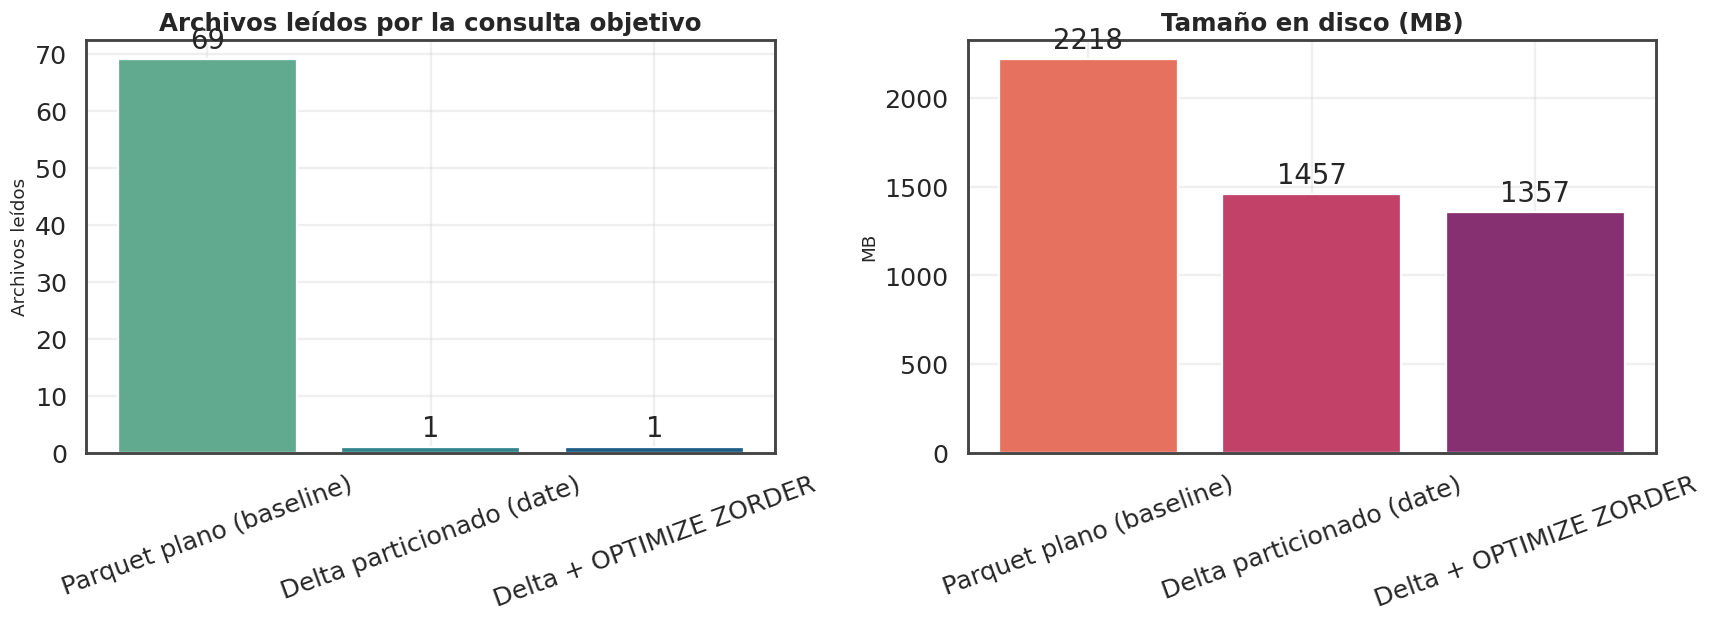

In [0]:
fig, (axf, axl) = plt.subplots(1, 2, figsize=(16, 6))

axf.bar(comparativa["estrategia"], comparativa["archivos_leidos_consulta"],
        color=sns.color_palette(OCEAN_SEQ, len(comparativa)))
axf.set_title("Archivos leídos por la consulta objetivo")
axf.set_ylabel("Archivos leídos"); axf.tick_params(axis="x", rotation=20)
for c in axf.containers:
    axf.bar_label(c, fmt="%.0f", padding=3)

axl.bar(comparativa["estrategia"], comparativa["MB"],
        color=sns.color_palette("flare", len(comparativa)))
axl.set_title("Tamaño en disco (MB)")
axl.set_ylabel("MB"); axl.tick_params(axis="x", rotation=20)
for c in axl.containers:
    axl.bar_label(c, fmt="%.0f", padding=3)
plt.show()

**Análisis (OPTIMIZE + comparativa).** 'OPTIMIZE ZORDER BY (LAT, LON)' reduce el tamaño de
**1,457 MB a 1,357 MB** al recomprimir y ordenar los datos por la clave espacial. El número de archivos
sube de 7 a 28 porque el comando reescribe cada partición diaria en varios ficheros ordenados por
lat/lon; esto no perjudica al propósito (la consulta sigue leyendo **1 archivo** gracias al pruning por
fecha) y **beneficia** a las consultas que además filtran por zona, al acercar físicamente los registros
vecinos (mejor *data skipping* espacial dentro del día). 

**Conclusión:** tabla **Delta
particionada por 'date' + ZORDER (LAT, LON)**. La evidencia lo sostiene: archivos leídos por la consulta
objetivo 69 → 1, y tamaño en disco 2,218 → 1,357 MB, con los planes de ejecución mostrando el paso de
'InMemoryFileIndex' (escaneo completo) a 'PreparedDeltaFileIndex' con 'PartitionFilters'.

## 6. Gobernanza básica (Req. 5)

Organizamos el trabajo en **Unity Catalog** (catálogo y esquema propios) y dejamos **comentarios y
metadatos** en las tablas. Buena parte ya se sembró en secciones anteriores; aquí lo consolidamos y
lo dejamos documentado en un solo lugar.

### 6.1 Estructura en Unity Catalog

- **Catálogo:** 'oceanwatch'
- **Esquema:** 'entrega1'
- **Volume:** 'landing' (datos crudos: zips, CSV, metadatos de ingesta)
- **Tablas:**
  - 'vessel_type_catalog' — códigos VesselType → categoría legible.
  - 'data_quality_report' — diagnóstico de calidad (insumo Entrega 2).
  - 'positions_delta' — posiciones saneadas, particionadas y optimizadas para el propósito.

In [0]:
# Comentarios a nivel de columna en la tabla principal (metadatos legibles)
column_comments = {
    "MMSI": "Identificador único del buque (9 dígitos, estándar AIS).",
    "BaseDateTime": "Marca temporal del mensaje AIS (UTC).",
    "LAT": "Latitud en grados decimales [-90, 90].",
    "LON": "Longitud en grados decimales [-180, 180].",
    "SOG": "Speed Over Ground en nudos (>=102.3 = no disponible).",
    "COG": "Course Over Ground en grados [0,360) (360 = no disponible).",
    "VesselType": "Código de tipo de buque (AIS); ver vessel_type_catalog.",
    "date": "Fecha derivada de BaseDateTime; columna de particionamiento.",
}
for col, comment in column_comments.items():
    safe = comment.replace("'", "\\'")
    try:
        spark.sql(f"ALTER TABLE {CATALOG}.{SCHEMA}.positions_delta ALTER COLUMN {col} COMMENT '{safe}'")
    except Exception as e:
        print(f"  (aviso) no se pudo comentar {col}: {e}")
print("Comentarios de columna aplicados a positions_delta.")

Comentarios de columna aplicados a positions_delta.


In [0]:
# Inventario de gobernanza: tablas del esquema con su comentario y propiedades
print("=== Tablas en", f"{CATALOG}.{SCHEMA}", "===")
display(spark.sql(f"SHOW TABLES IN {CATALOG}.{SCHEMA}"))

for t in ["vessel_type_catalog", "data_quality_report", "positions_delta"]:
    print(f"\n----- DESCRIBE DETAIL {t} -----")
    try:
        display(spark.sql(f"DESCRIBE DETAIL {CATALOG}.{SCHEMA}.{t}")
                .select("format", "location", "numFiles", "sizeInBytes", "partitionColumns"))
    except Exception as e:
        print("  (aviso)", e)

=== Tablas en oceanwatch.entrega1 ===


database,tableName,isTemporary
entrega1,data_quality_report,false
entrega1,positions_delta,false
entrega1,vessel_type_catalog,false
,ais_raw,true



----- DESCRIBE DETAIL vessel_type_catalog -----


format,location,numFiles,sizeInBytes,partitionColumns
delta,,1,1636,List()



----- DESCRIBE DETAIL data_quality_report -----


format,location,numFiles,sizeInBytes,partitionColumns
delta,,1,2440,List()



----- DESCRIBE DETAIL positions_delta -----


format,location,numFiles,sizeInBytes,partitionColumns
delta,,28,1357405275,List(date)


**Análisis.** El trabajo queda organizado en un único catálogo/esquema
('oceanwatch.entrega1') con un Volume gobernado para los datos crudos y tres tablas con propósito claro:
el **catálogo de tipos** (traduce códigos a categorías legibles), el **reporte de calidad** (insumo
directo de la Entrega 2) y **'positions_delta'** (dato saneado y optimizado). Los comentarios a nivel de
tabla y de columna (incluida la documentación de los sentinelas AIS como 102.3, 360 y 511) hacen el
esquema **autodescriptivo**: cualquier consumidor entiende el significado y los rangos válidos sin salir
de Unity Catalog. Esto conecta las tres piezas del proyecto —calidad, propósito de consulta y
gobernanza— en un lakehouse trazable de punta a punta.

# Fuera de este notebook
- **Req. 6 — Repositorio y bitácora:** documentados en el 'README.md' del repositorio.


#### Artefactos generados en Unity Catalog
Con los parámetros por defecto ('oceanwatch.entrega1'):
- 'oceanwatch.entrega1.vessel_type_catalog' — códigos VesselType → categoría.
- 'oceanwatch.entrega1.data_quality_report' — diagnóstico de calidad (insumo Entrega 2).
- 'oceanwatch.entrega1.positions_delta' — posiciones saneadas, particionadas por 'date' y optimizadas.
- Volume '/Volumes/oceanwatch/entrega1/landing' — zips, CSV, Parquet baseline y manifiesto de ingesta.